# 06A. Классификация табличных данных

### Условие

Требуется решить задачу классификации на наборе данных, представленных в виде таблице, с использованием каждого из следующих методов

* One rule
* Логистическая регрессия
* k ближайших соседей
* Наивный байесовский классификатор
* Деревья решений
* Градиентный бустинг
* Метод опорных векторов
* Полносвязная нейронная сеть (multi layer perceptron)
* Ансамбль моделей

Требуется провести предобработку данных, сравнительный анализ использованных методов и исследование важности признаков в датасете.
Требования к датасету

* Датасет должен содержать не менее 10000 примеров и предназначен для решения задачи multiclass classification.
* Датасет должен быть согласован с преподавателем.
* Один и тот же датасет может быть использован не более чем двумя студентами.

Распределение баллов

Максимальное количество баллов за задачу — 10.

* Работа с датасетом, до +2
* Обучение моделей, до +6
* Тестирование моделей, до +2

* [Dataset](https://www.kaggle.com/datasets/purumalgi/music-genre-classification)

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import sklearn as sk
import sklearn.metrics as metrics

# Data Preparation

In [2]:
df = pd.read_csv('train.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         17996 non-null  str    
 1   Track Name          17996 non-null  str    
 2   Popularity          17568 non-null  float64
 3   danceability        17996 non-null  float64
 4   energy              17996 non-null  float64
 5   key                 15982 non-null  float64
 6   loudness            17996 non-null  float64
 7   mode                17996 non-null  int64  
 8   speechiness         17996 non-null  float64
 9   acousticness        17996 non-null  float64
 10  instrumentalness    13619 non-null  float64
 11  liveness            17996 non-null  float64
 12  valence             17996 non-null  float64
 13  tempo               17996 non-null  float64
 14  duration_in min/ms  17996 non-null  float64
 15  time_signature      17996 non-null  int64  
 16  Class          

In [3]:
df

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,6
3,Deno,Lingo (feat. J.I & Chunkz),66.0,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.0,4,5
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17991,Green-House,Find Home,35.0,0.166,0.109,7.0,-17.100,0,0.0413,0.993000,0.824000,0.0984,0.1770,171.587,193450.0,3,6
17992,Micatone,All Gone,27.0,0.638,0.223,11.0,-10.174,0,0.0329,0.858000,0.000016,0.0705,0.3350,73.016,257067.0,4,2
17993,Smash Hit Combo,Peine perdue,34.0,0.558,0.981,4.0,-4.683,0,0.0712,0.000030,0.000136,0.6660,0.2620,105.000,216222.0,4,8
17994,Beherit,Salomon's Gate,29.0,0.215,0.805,6.0,-12.757,0,0.1340,0.001290,0.916000,0.2560,0.3550,131.363,219693.0,4,8


In [4]:
df.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,17568.000000,17996.000000,17996.000000,15982.000000,17996.000000,17996.000000,17996.000000,17996.000000,13619.000000,17996.000000,17996.000000,17996.000000,1.799600e+04,17996.000000,17996.000000
mean,44.512124,0.543433,0.662777,5.952447,-7.910660,0.636753,0.079707,0.247082,0.177562,0.196170,0.486208,122.623294,2.007445e+05,3.924039,6.695821
std,17.426928,0.166268,0.235373,3.196854,4.049151,0.480949,0.083576,0.310632,0.304048,0.159212,0.240195,29.571527,1.119891e+05,0.361618,3.206073
min,1.000000,0.059600,0.000020,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.018300,30.557000,5.016500e-01,1.000000,0.000000
25%,33.000000,0.432000,0.509000,3.000000,-9.538000,0.000000,0.034800,0.004300,0.000089,0.097500,0.297000,99.620750,1.663370e+05,4.000000,5.000000
50%,44.000000,0.545000,0.700000,6.000000,-7.016000,1.000000,0.047400,0.081400,0.003910,0.129000,0.481000,120.065500,2.091600e+05,4.000000,8.000000
75%,56.000000,0.659000,0.860000,9.000000,-5.189000,1.000000,0.083000,0.434000,0.200000,0.258000,0.672000,141.969250,2.524900e+05,4.000000,10.000000
max,100.000000,0.989000,1.000000,11.000000,1.355000,1.000000,0.955000,0.996000,0.996000,1.000000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


In [5]:
df.nunique()

Artist Name            9149
Track Name            15129
Popularity              100
danceability            909
energy                 1208
key                      11
loudness               9002
mode                      2
speechiness            1194
acousticness           3930
instrumentalness       4253
liveness               1459
valence                1320
tempo                 13562
duration_in min/ms    14121
time_signature            4
Class                    11
dtype: int64

In [6]:
df = df.drop(['Artist Name', 'Track Name'], axis=1)

array([[<Axes: title={'center': 'Popularity'}>,
        <Axes: title={'center': 'danceability'}>,
        <Axes: title={'center': 'energy'}>,
        <Axes: title={'center': 'key'}>],
       [<Axes: title={'center': 'loudness'}>,
        <Axes: title={'center': 'mode'}>,
        <Axes: title={'center': 'speechiness'}>,
        <Axes: title={'center': 'acousticness'}>],
       [<Axes: title={'center': 'instrumentalness'}>,
        <Axes: title={'center': 'liveness'}>,
        <Axes: title={'center': 'valence'}>,
        <Axes: title={'center': 'tempo'}>],
       [<Axes: title={'center': 'duration_in min/ms'}>,
        <Axes: title={'center': 'time_signature'}>,
        <Axes: title={'center': 'Class'}>, <Axes: >]], dtype=object)

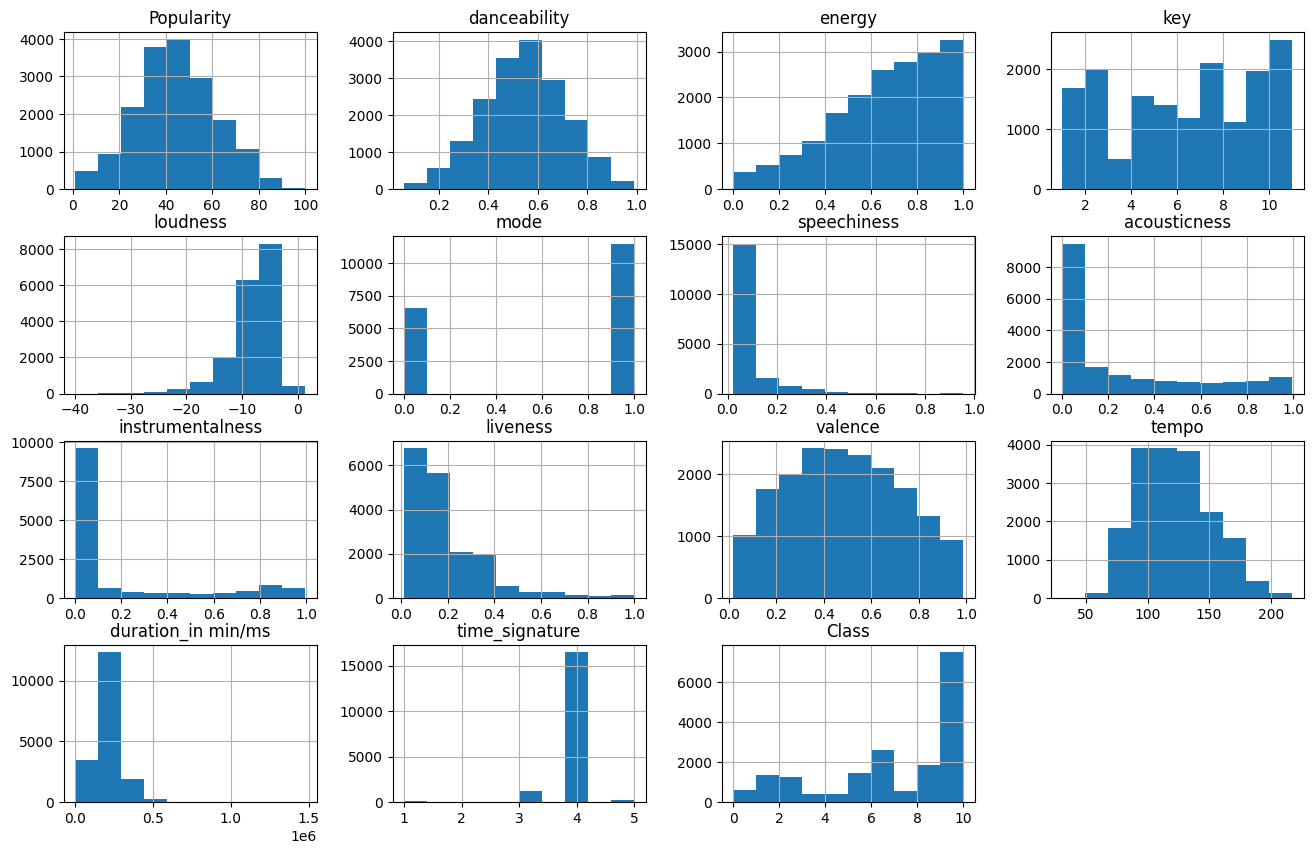

In [7]:
df.hist(figsize=(16, 10))

In [8]:
df1 = df.copy()

In [9]:
df.columns[df.isna().any()]

Index(['Popularity', 'key', 'instrumentalness'], dtype='str')

In [10]:
def plot_with_nan(_df: pd.DataFrame, col: str, is_nan: bool = True) -> tuple:
    _c = _df[col].value_counts(dropna=False)
    _c_na = _c.get(np.nan, 0)
    if _c_na != 0:
        _c.drop([np.nan], inplace=True)
    _s = np.array(list(_c.items()))

    _si = np.argsort(_s[:, 0], axis=None)
    _s_sort = _s[_si]

    plt.grid()
    plt.plot(_s_sort[:, 0], _s_sort[:, 1])
    if is_nan:
        plt.plot([_s_sort[:, 0].min(), _s_sort[:, 0].max()], [_c_na, _c_na], 'r')
    print("None count:", _c_na)
    return _df[col].mean(), _df[col].median(), _df[col].mode().to_list()

None count: 428


(np.float64(44.51212431693989), np.float64(44.0), [42.0])

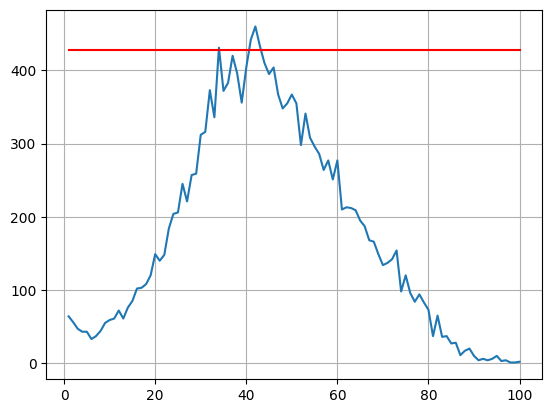

In [11]:
plot_with_nan(df, 'Popularity')

In [12]:
df1['Popularity'] = df1['Popularity'].fillna(df['Popularity'].median())

None count: 0


(np.float64(44.49994443209602), np.float64(44.0), [44.0])

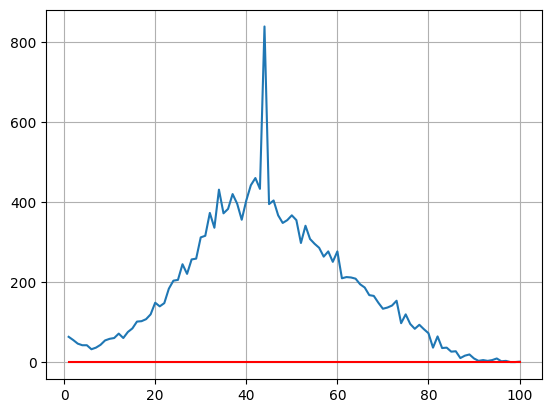

In [13]:
plot_with_nan(df1, 'Popularity')

None count: 2014


(np.float64(5.952446502315104), np.float64(6.0), [7.0])

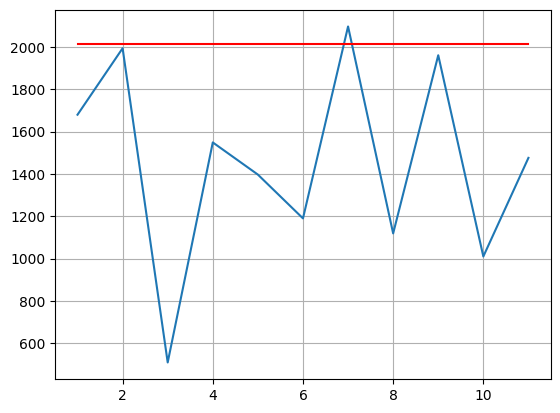

In [14]:
plot_with_nan(df, 'key')

In [15]:
df1['key'] = df1['key'].fillna(df['key'].mode()[0])

None count: 0


(np.float64(6.069682151589242), np.float64(7.0), [7.0])

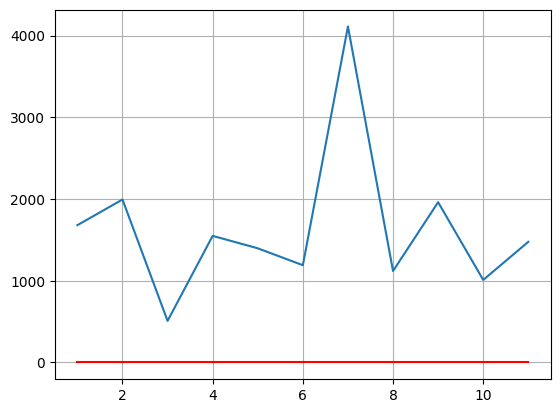

In [16]:
plot_with_nan(df1, 'key')

None count: 4377


(np.float64(0.17756192536603277), np.float64(0.00391), [0.000109])

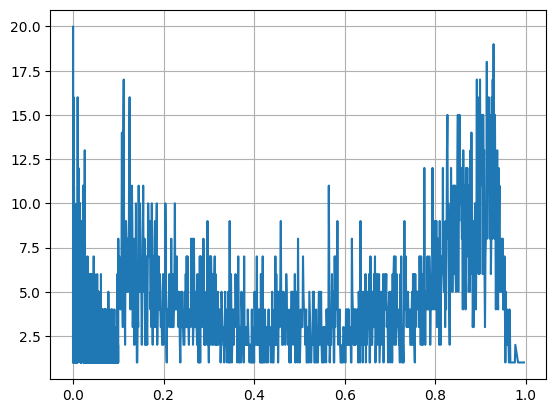

In [17]:
plot_with_nan(df, 'instrumentalness', is_nan=False)

<Axes: >

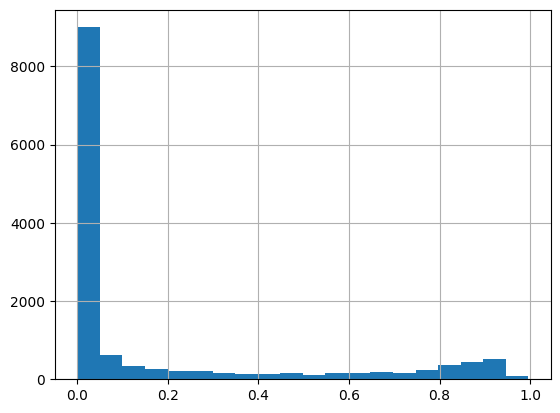

In [18]:
df['instrumentalness'].hist(bins=20)

In [19]:
df1['instrumentalness'] = df1['instrumentalness'].fillna(df['instrumentalness'].median())

None count: 0


(np.float64(0.13532617979328737), np.float64(0.00391), [0.00391])

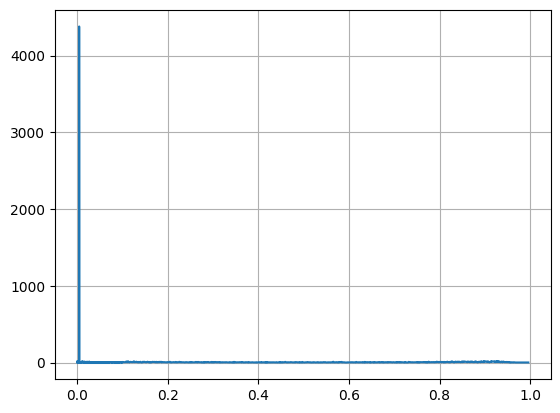

In [20]:
plot_with_nan(df1, 'instrumentalness', is_nan=False)

In [21]:
df1.corr()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
Popularity,1.000000,0.165469,0.050873,0.005303,0.122428,0.016321,0.031329,-0.123594,-0.170386,-0.071643,0.054171,-0.005924,-0.029972,0.066235,0.158493
danceability,0.165469,1.000000,-0.093838,0.005660,0.059723,-0.067135,0.199042,0.009055,-0.219255,-0.109485,0.444548,-0.183527,-0.121624,0.137455,-0.097681
energy,0.050873,-0.093838,1.000000,0.011090,0.767869,-0.035880,0.125427,-0.745963,-0.151817,0.195634,0.222998,0.210224,0.245768,0.145281,0.217328
key,0.005303,0.005660,0.011090,1.000000,0.000395,-0.094606,-0.003230,-0.006544,0.002558,0.015468,0.031422,0.013341,0.012032,0.004881,-0.007495
loudness,0.122428,0.059723,0.767869,0.000395,1.000000,-0.033650,0.096027,-0.612824,-0.348796,0.112022,0.181086,0.164272,0.172010,0.127775,0.177872
mode,0.016321,-0.067135,-0.035880,-0.094606,-0.033650,1.000000,-0.074609,0.024035,-0.016565,-0.001563,-0.002986,0.021211,-0.069307,-0.019989,-0.044740
speechiness,0.031329,0.199042,0.125427,-0.003230,0.096027,-0.074609,1.000000,-0.086648,-0.100555,0.070406,0.053885,0.048948,0.005044,0.056237,-0.059349
acousticness,-0.123594,0.009055,-0.745963,-0.006544,-0.612824,0.024035,-0.086648,1.000000,0.146809,-0.111393,-0.122547,-0.168318,-0.322583,-0.133936,-0.237138
instrumentalness,-0.170386,-0.219255,-0.151817,0.002558,-0.348796,-0.016565,-0.100555,0.146809,1.000000,-0.041411,-0.223621,-0.028771,0.036411,-0.072357,-0.038072
liveness,-0.071643,-0.109485,0.195634,0.015468,0.112022,-0.001563,0.070406,-0.111393,-0.041411,1.000000,0.021076,0.033515,0.053885,0.021546,0.045309


In [22]:
df_y = df1['Class']
df_x = df1.drop(['Class'], axis=1)

In [23]:
X_train0, X_test0, y_train, y_test = sk.model_selection.train_test_split(df_x, df_y, test_size=0.2, random_state=42)

In [24]:
scaler = sk.preprocessing.StandardScaler().fit(X_train0)

In [25]:
X_train = pd.DataFrame(scaler.transform(X_train0), columns=df_x.columns)
X_test = pd.DataFrame(scaler.transform(X_test0), columns=df_x.columns)
df_s = pd.DataFrame(scaler.transform(df_x), columns=df_x.columns)

In [26]:
X_train

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,-1.309380,1.284402,0.718567,0.307714,0.684887,-1.324845,0.127420,-0.352733,-0.479186,-0.627458,0.838082,-0.625154,-0.119851,0.208346
1,1.813350,0.754968,0.101825,-0.021618,0.527905,-1.324845,0.467598,-0.766054,-0.479186,1.954096,-0.630106,-1.032872,0.951875,0.208346
2,0.945925,1.591232,0.131599,-1.668282,-0.131715,0.754805,2.150834,-0.100865,-0.493126,1.114668,1.204089,0.788205,-0.097304,0.208346
3,-1.309380,0.484236,0.182640,1.625045,0.473367,-1.324845,2.292085,-0.693723,-0.479186,1.358979,-0.513649,-0.958772,0.064288,0.208346
4,0.483298,0.526350,-0.680799,-1.668282,0.018143,-1.324845,-0.182155,0.260791,-0.479186,-0.351199,1.108428,2.914548,-0.436652,0.208346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14391,0.136328,-0.442272,0.846169,-0.021618,0.598657,-1.324845,0.373431,-0.778841,-0.479186,-0.858614,-0.056140,1.335661,0.202460,0.208346
14392,0.020671,0.375942,0.174133,0.307714,0.814600,0.754805,-0.333999,-0.700827,-0.493368,-0.570452,0.829763,-0.527489,-0.041303,0.208346
14393,-0.094985,0.129275,-0.829668,0.637047,-0.252583,-1.324845,-0.391676,1.768767,2.794990,0.124895,-1.694853,1.092257,0.085317,0.208346
14394,-0.152814,0.508301,0.561192,1.625045,0.243175,-1.324845,-0.612969,-0.782006,-0.493343,-0.401314,1.016926,0.417773,0.971590,0.208346


# Models

### OneRule

In [27]:
from sklearn.pipeline import Pipeline

In [28]:
N_CLASSES = len(np.unique(df_y))
class_counts = np.bincount(df_y)
class_weights = 1 / class_counts
class_priors = len(df_y) / (N_CLASSES * class_counts)

In [29]:
def confusion_matrix(y_true, y_pred, ax=None, normalize=None):
    if not ax:
        _, ax = plt.subplots(figsize=(7, 7))
    metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, colorbar=False, normalize=normalize)

In [30]:
def plot_permutation_importance(clf, X, y, ax=None, scoring='balanced_accuracy', n_repeats: int = 5):
    print(f"Calc permutation importance", end="")
    if not ax:
        _, ax = plt.subplots(figsize=(7, 7))
    result = sk.inspection.permutation_importance(clf, X, y, n_repeats=n_repeats, random_state=42, n_jobs=10, scoring=scoring)
    perm_sorted_idx = result.importances_mean.argsort()

    tick_labels_dict = {"tick_labels": X.columns[perm_sorted_idx]}
    ax.boxplot(result.importances[perm_sorted_idx].T, vert=False, **tick_labels_dict)
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel(f"Decrease in {scoring!r}")
    ax.set_title("Permutation Importance")
    
    print(f"\r", end="")
    return ax

In [31]:
def kfold_cross_val(model, X, y, n_splits=5, shuffle=True, random_state=None, scoring='balanced_accuracy'):
    class PD_DF:
        def fit(self, _X, _y):
            return self

        def transform(self, _X):
            return pd.DataFrame(_X, columns=X.columns)
        
        def __repr__(self):
            return f"{self.__class__.__name__}()"
        

    print(f"Calc kfold cross val{' '*20}", end="")
    pipeline = Pipeline([
        ('scaler', sk.preprocessing.StandardScaler()),
        ('pd', PD_DF()),
        ('clf', model)
    ])

    accs = sk.model_selection.cross_val_score(pipeline, X, y, cv=sk.model_selection.KFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state), 
                                              scoring=scoring, 
                                              n_jobs=5)
    print("\r", end="")
    return accs

In [32]:
def feature_importance(*models: list):
    return pd.DataFrame({i: model.feature_importances_ for i, model in enumerate(models)}, X_train.columns).sort_values(by=0, ascending=False)

In [33]:
saved_accuracy = {}

In [103]:
def mega_info(model, normalize=None, fit_kwargs={}, is_kflod: bool = True, kfolds: int = 5, permut_repeats: int = 5):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

    model.fit(X_train, y_train, **fit_kwargs)
    y_pred = model.predict(X_test)
    acc = model.score(X_test, y_test)
    print(f"Accuracy: {acc:.4f}")
    b_acc = metrics.balanced_accuracy_score(y_test, y_pred)
    print(f"Balanced Accuracy: {b_acc:.4f}")
    confusion_matrix(y_test, y_pred, ax=ax2, normalize=normalize)
    if permut_repeats:
        plot_permutation_importance(model, X_train, y_train, ax=ax1, n_repeats=permut_repeats)
    
    if is_kflod:
        kfold = kfold_cross_val(model, X_train, y_train, n_splits=kfolds)
        print(f"{kfolds}-fold Cross Val: {kfold}; {kfold.mean():.4f}")
    else:
        kfold = np.array([acc])

    saved_accuracy[model] = (acc, b_acc, kfold.mean())
    return model

In [143]:
class OneRule(sk.base.ClassifierMixin, sk.base.BaseEstimator):
    def __init__(self, bins: int = 20, crit_nunique: int = 30, weighted_type: int = 1):
        self.is_fitted_ = False
        self.classes_ = None
        self.bins = bins
        self.crit_nunique = crit_nunique
        self.weighted_type = weighted_type

        self.dataframe: pd.DataFrame = None

        self.best_col = None
        self.errors: dict[str, float] = None
        self.estimators: dict[str, pd.Series] = None
        self.intervals: dict[str, np.ndarray] = None

    def fit(self, X: pd.DataFrame | np.ndarray, y: pd.Series | np.ndarray = None):
        _X = pd.DataFrame(X.copy())
        y = pd.Series(y.copy())
        self.classes_ = np.unique(y)
        class_counts = np.bincount(y)

        weights = [1] * len(self.classes_)
        if self.weighted_type == 1:
            weights = 1. / class_counts
        elif self.weighted_type == 2:
            weights = len(y) / (len(self.classes_) * class_counts)
        class_weights = pd.Series(weights, index=self.classes_)

        self.intervals = {}

        for _col in _X.columns[_X.nunique() > self.crit_nunique]:
            _categories, _bins = pd.cut(
                _X[_col],
                self.bins,
                labels=False,
                retbins=True
            )
            _bins[0] = -np.inf
            _bins[-1] = np.inf
            self.intervals[_col] = _bins
            _X[_col] = _categories

        errors = []
        estimators = {}

        for _col in _X.columns:
            _cross = pd.crosstab(_X[_col], y)
            if self.weighted_type in (1, 2):
                _cross = _cross.mul(class_weights, axis=1)

            total_error = _cross.sum().sum() - _cross.max(axis=1).sum()
            estimators[_col] = _cross.idxmax(axis=1)
            errors.append(total_error)

        self.errors = dict(zip(_X.columns, errors))
        self.estimators = estimators
        self.dataframe = _X

        self.best_col = _X.columns[np.argmin(errors)]

        self.is_fitted_ = True
        return self

    def predict(self, X, col: str = None):
        sk.utils.validation.check_is_fitted(self)

        col = col or self.best_col
        data = pd.DataFrame(X)[col]
        if col in self.intervals:
            data = pd.cut(data, self.intervals[col], labels=False)
        return self.estimators[col][data].to_numpy()

    def balanced_score(self, X, y, *, sample_weight=None, adjusted=False):
        sk.utils.validation.check_is_fitted(self)
        return metrics.balanced_accuracy_score(y, self.predict(X), sample_weight=sample_weight, adjusted=adjusted)

Accuracy: 0.0458
Balanced Accuracy: 0.0835
10-fold Cross Val: [0.0900262  0.09639794 0.07685973 0.10633533 0.07025648 0.08256595
 0.11138752 0.06186755 0.07453813 0.08538732]; 0.0856


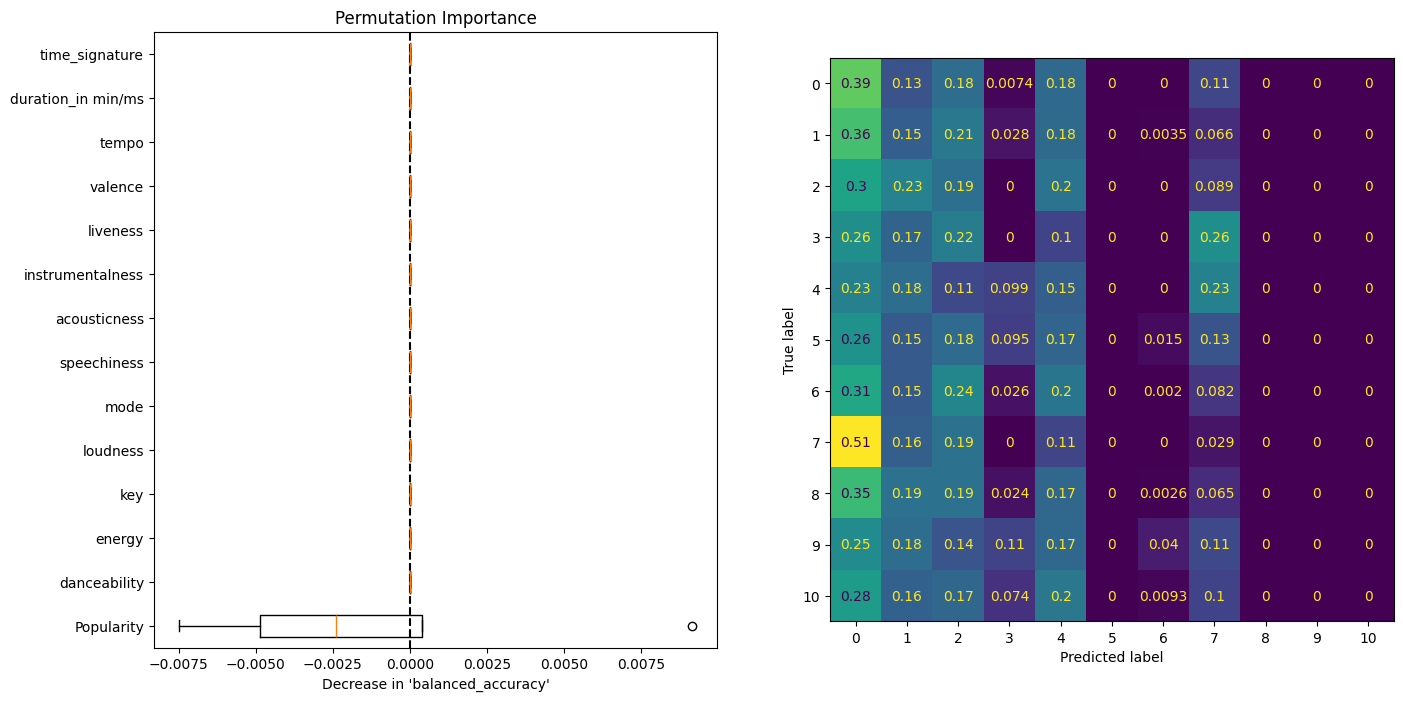

In [145]:
OR = mega_info(OneRule(), 'true', kfolds=10, permut_repeats=5)

In [147]:
OR.best_col

'Popularity'

In [148]:
OR.errors

{'Popularity': np.float64(7.7260656436821),
 'danceability': np.float64(7.77313223677104),
 'energy': np.float64(7.743060632956415),
 'key': np.float64(7.816906558812471),
 'loudness': np.float64(7.834070927953045),
 'mode': np.float64(7.9412193924363805),
 'speechiness': np.float64(7.838425322848002),
 'acousticness': np.float64(7.783337998146961),
 'instrumentalness': np.float64(7.825392412079288),
 'liveness': np.float64(7.798289615499663),
 'valence': np.float64(7.747318090040354),
 'tempo': np.float64(7.7824677224182235),
 'duration_in min/ms': np.float64(7.838016980784165),
 'time_signature': np.float64(7.934192907078842)}

###

In [39]:
from sklearn.linear_model import LogisticRegression

Accuracy: 0.4872
Balanced Accuracy: 0.5225
5-fold Cross Val: [0.50705662 0.51642314 0.53345933 0.53221235 0.52908598]; 0.5236


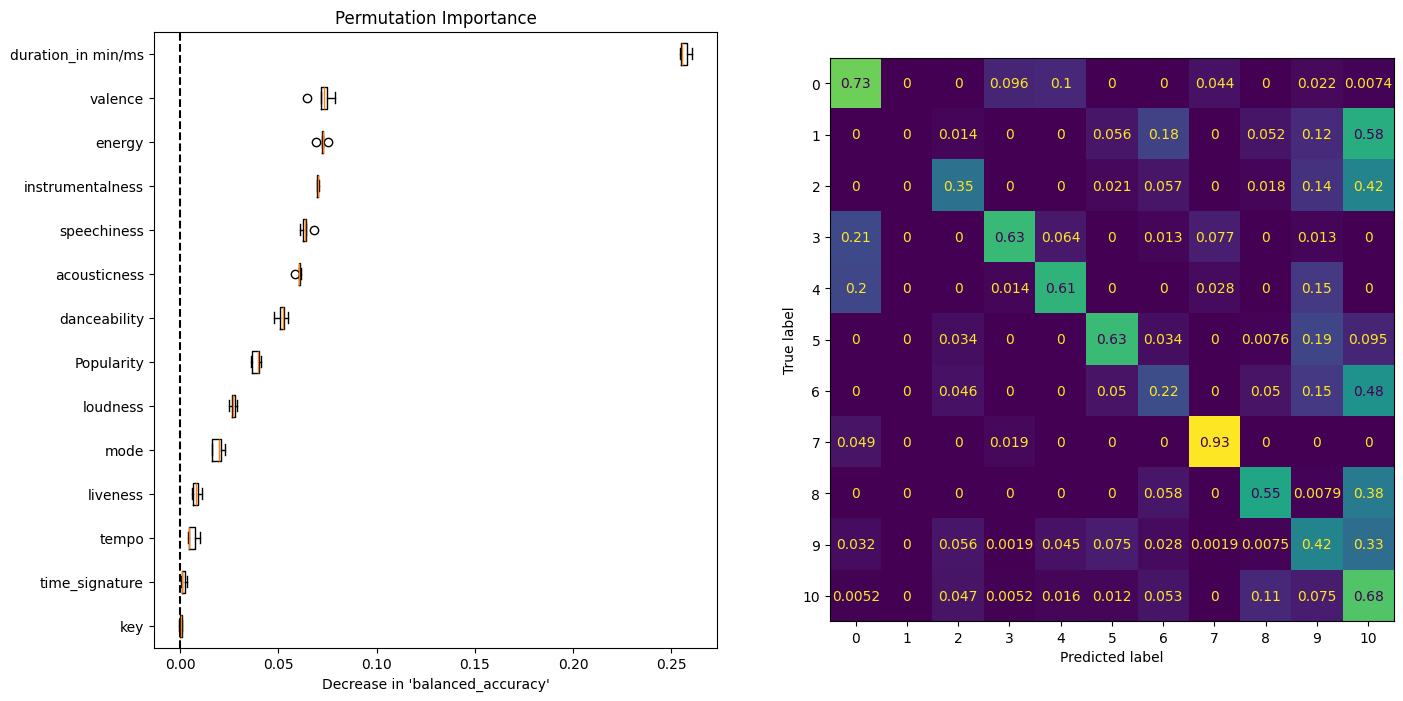

In [40]:
lr1 = mega_info(LogisticRegression(max_iter=10000), 'true')

In [41]:
lr1.intercept_, lr1.coef_

(array([ -4.63565602,   4.41920285,   3.52022416,  -6.27999438,
         -4.68456463,   3.01199365,   5.03721013, -13.21225268,
          2.90401355,   4.42133876,   5.49848461]),
 array([[-3.52754199e-01,  1.75652431e-01, -4.78860986e-01,
          2.52127413e-02,  1.80452246e-01, -1.13955231e-01,
         -1.89324115e-01,  5.96502628e-01,  8.26698507e-02,
         -4.25772517e-01, -5.28880690e-01,  2.29513631e-01,
         -3.77069539e+00,  4.62450175e-03],
        [ 2.84971386e-01, -1.71455685e-01,  3.57603825e-01,
          1.45501166e-02, -2.60849864e-01,  1.30109615e-01,
          8.60558650e-02, -4.76772723e-01,  2.52723336e-01,
          6.21629901e-02, -3.91105082e-03, -3.53279848e-02,
          2.33536408e+00,  4.34287226e-02],
        [-6.07977621e-01, -3.22434776e-01, -3.44025416e-01,
          1.01123787e-01,  5.81854614e-02,  1.81938732e-01,
          4.39713307e-02,  1.49080253e-02, -1.90184594e-01,
          2.10539161e-01,  8.97011801e-01,  1.37315859e-02,
          2.

Accuracy: 0.4394
Balanced Accuracy: 0.5651
5-fold Cross Val: [0.54891045 0.58050085 0.5459829  0.56239371 0.57016763]; 0.5616


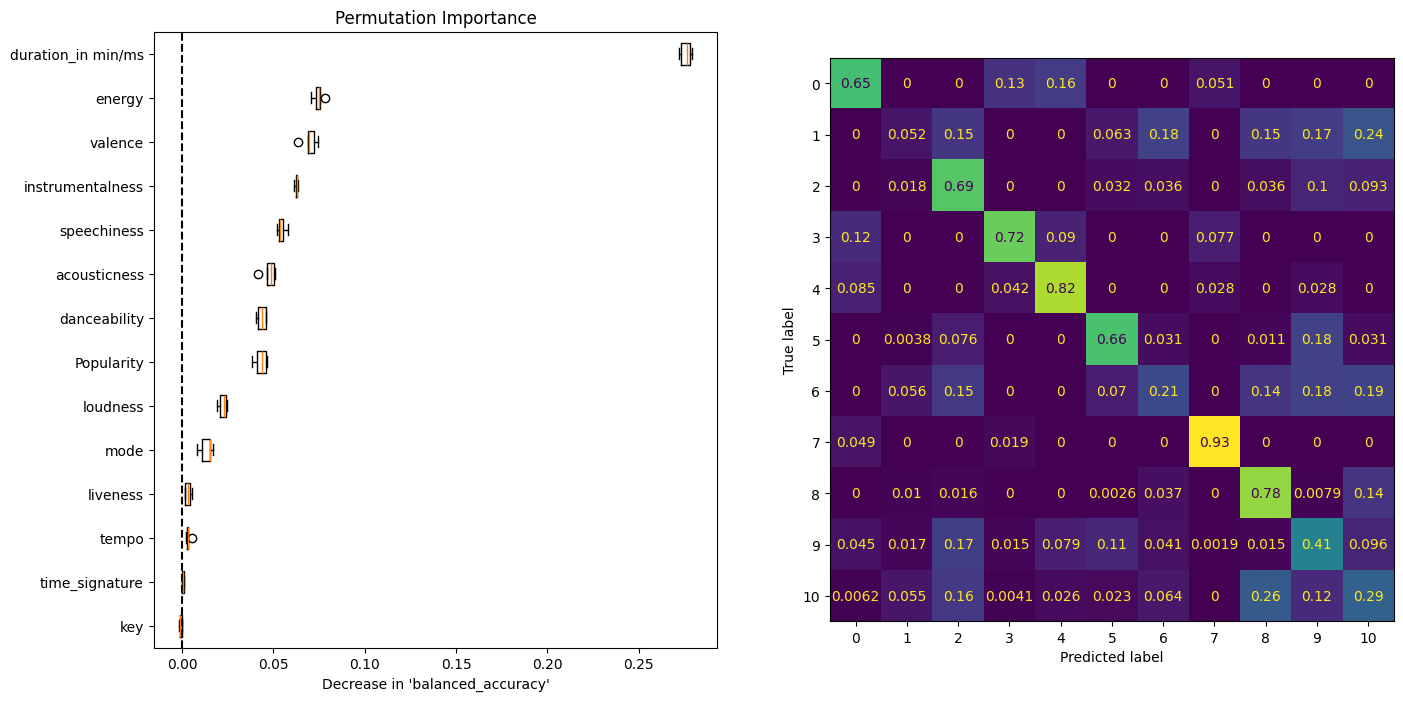

In [42]:
lr2 = mega_info(LogisticRegression(max_iter=10000, class_weight='balanced'), 'true')

In [43]:
lr2.intercept_, lr2.coef_

(array([ -4.67430878,   4.97208539,   4.10400843,  -6.10886997,
         -4.88559292,   3.47328836,   4.93713911, -14.08406392,
          3.13776076,   4.36676074,   4.76179279]),
 array([[-4.20105091e-01,  1.27025050e-01, -4.45237732e-01,
         -2.16103799e-03,  1.71856359e-01, -1.39863776e-01,
         -1.99826765e-01,  6.42118649e-01, -4.88614377e-02,
         -4.43414081e-01, -5.28842509e-01,  2.68649956e-01,
         -4.23033117e+00,  1.43545071e-02],
        [ 2.63540505e-01, -1.41590782e-01,  2.95736666e-01,
          2.55289548e-02, -2.09966865e-01,  1.46580825e-01,
          1.13553735e-01, -5.40987745e-01,  3.10679534e-01,
          6.89446150e-02, -3.44226424e-02, -4.47545193e-02,
          2.69791581e+00,  5.00444262e-02],
        [-6.97679826e-01, -2.95989722e-01, -3.88197675e-01,
          1.04430929e-01,  9.12546072e-02,  1.80617272e-01,
          4.61516625e-02,  3.54372983e-03, -1.44081057e-01,
          2.72738535e-01,  8.73465086e-01, -1.35492609e-02,
          3.

Accuracy: 0.4397
Balanced Accuracy: 0.5654
5-fold Cross Val: [0.55962254 0.5687729  0.56900343 0.55320026 0.56181247]; 0.5625


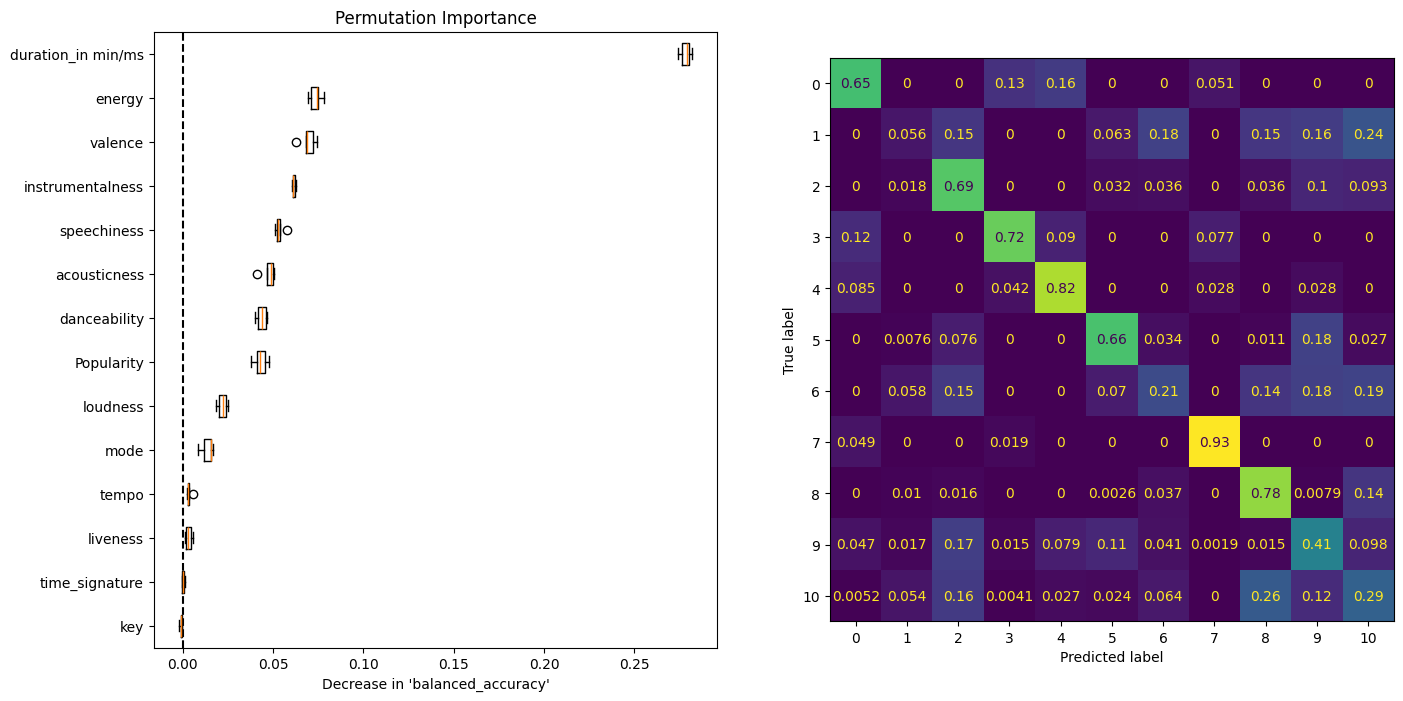

In [44]:
lr3 = mega_info(LogisticRegression(max_iter=10000, l1_ratio=1, solver='saga', class_weight='balanced'), 'true')

In [45]:
lr3.intercept_, lr3.coef_

(array([ -6.71037697,   6.5335693 ,   5.66800751,  -8.61286366,
         -4.34592433,   5.03309919,   6.49729619, -21.01874635,
          4.69441142,   5.93739594,   6.32413175]),
 array([[-5.13121900e-01,  1.56879216e-01, -3.17824932e-01,
          0.00000000e+00,  1.53496770e-01, -1.53988315e-01,
         -2.71939755e-01,  7.19395557e-01,  6.35874173e-02,
         -5.29281686e-01, -4.60477429e-01,  2.59827649e-01,
         -9.00840648e+00,  0.00000000e+00],
        [ 1.48228373e-01, -4.92698296e-02,  4.52774063e-01,
          1.42747359e-02, -8.95314061e-02,  1.70000288e-01,
          4.86119630e-03, -5.01209661e-01,  2.41762811e-01,
          0.00000000e+00,  2.92894321e-02, -3.12301322e-02,
          0.00000000e+00,  4.20867003e-02],
        [-8.07841635e-01, -2.02778199e-01, -2.23721422e-01,
          9.17651679e-02,  2.03618523e-01,  2.03609361e-01,
         -5.93290774e-02,  4.10220727e-02, -2.14789254e-01,
          2.02420857e-01,  9.35220395e-01,  0.00000000e+00,
          5.

In [46]:
pd.DataFrame(lr3.coef_.T, X_train.columns)

,0,1,2,3,4,5,6,7,8,9,10
Popularity,-0.513122,0.148228,-0.807842,-0.807399,0.627931,0.000000,-0.152184,-0.069491,0.045479,0.197046,0.169687
danceability,0.156879,-0.049270,-0.202778,-0.616947,0.134689,1.315666,0.115828,0.000000,-0.418398,0.658793,-0.330262
energy,-0.317825,0.452774,-0.223721,0.309347,0.000000,-0.051588,0.269779,-1.321415,2.123040,-0.322172,0.693082
key,0.000000,0.014275,0.091765,0.005527,-0.034220,-0.032842,0.061504,-0.082005,-0.077402,0.005273,-0.007903
loudness,0.153497,-0.089531,0.203619,-0.044954,0.000000,0.513055,0.037854,-0.757292,-0.328004,1.106992,-0.080819
mode,-0.153988,0.170000,0.203609,-0.492994,0.767806,-0.012605,0.182385,-0.640278,0.000000,-0.087420,0.159556
speechiness,-0.271940,0.004861,-0.059329,0.133588,-0.920442,1.060856,0.086048,-0.757888,0.000000,0.020278,-0.300571
acousticness,0.719396,-0.501210,0.041022,1.655162,0.093821,-0.495427,-0.403060,1.140620,-1.143299,0.000000,-0.528923
instrumentalness,0.063587,0.241763,-0.214789,0.000000,-0.954926,-0.468297,0.395541,1.503334,0.121450,-0.522352,-0.168688
liveness,-0.529282,0.000000,0.202421,-0.156279,-0.349482,0.204374,0.021243,-0.454339,-0.000338,0.148857,0.090419


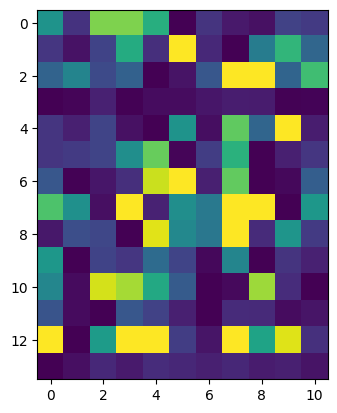

In [47]:
plt.imshow(np.clip(np.abs(lr3.coef_.T), 0, 1))

### kNN

In [48]:
from sklearn.neighbors import KNeighborsClassifier

Accuracy: 0.4253
Balanced Accuracy: 0.4942
5-fold Cross Val: [0.52197622 0.48329698 0.49213527 0.4915016  0.49342843]; 0.4965


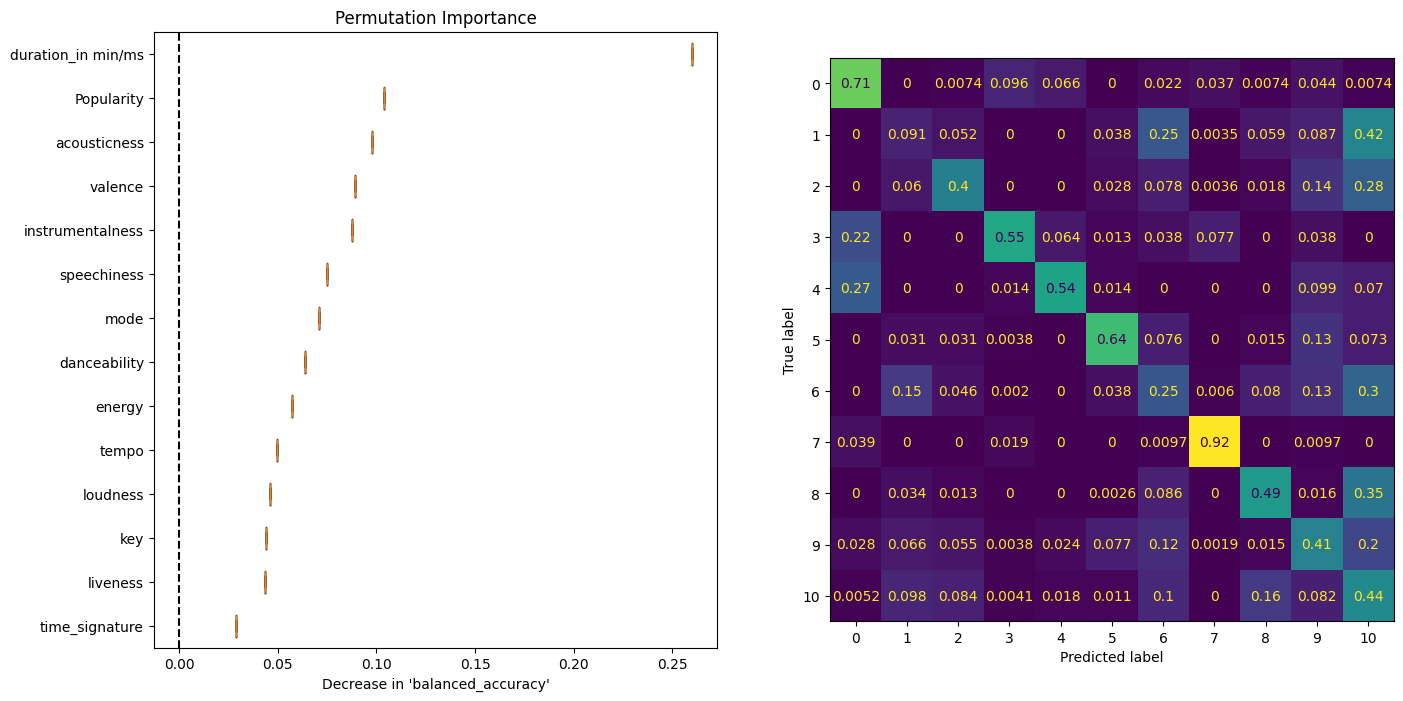

In [49]:
knn5 = mega_info(KNeighborsClassifier(), 'true', permut_repeats=1)

Accuracy: 0.4092
Balanced Accuracy: 0.4744
5-fold Cross Val: [0.5039837  0.47333818 0.46535354 0.47904971 0.46206549]; 0.4768


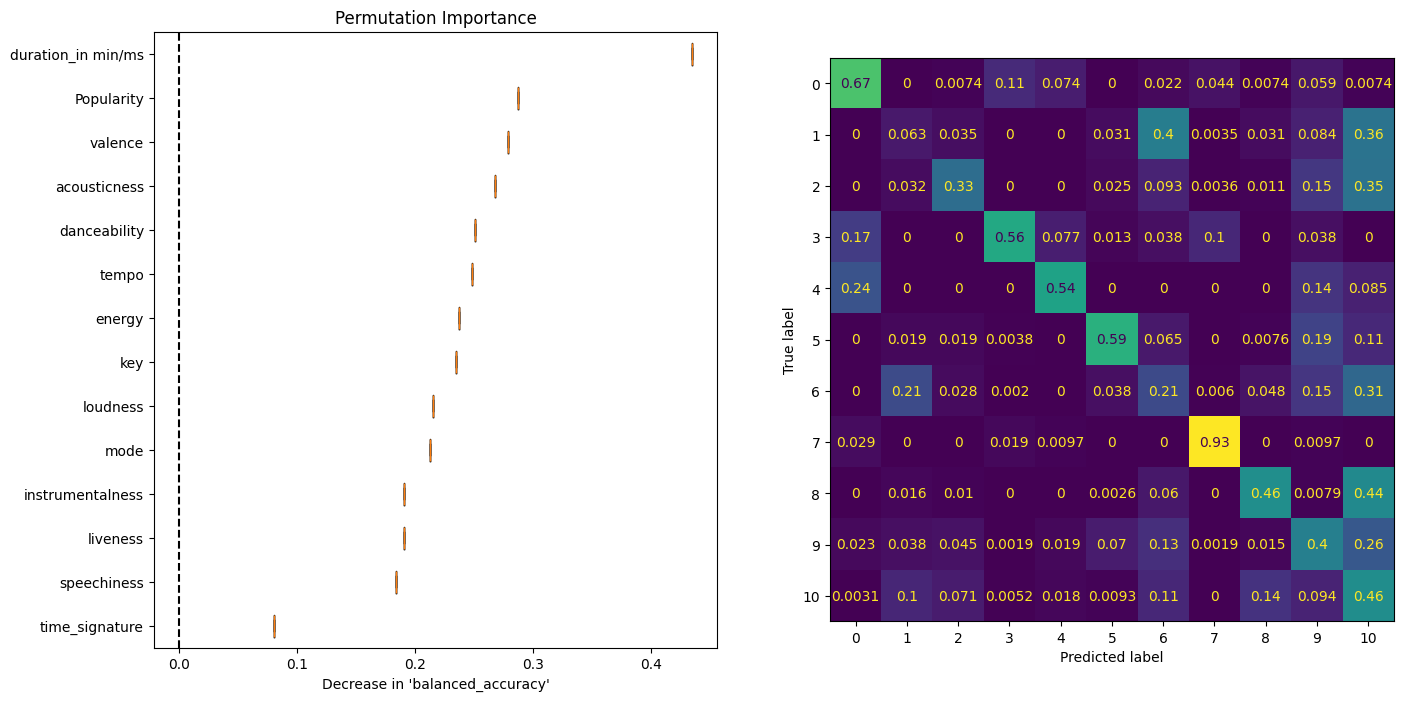

In [50]:
knn5w = mega_info(KNeighborsClassifier(weights='distance'), 'true', permut_repeats=1)

Accuracy: 0.4844
Balanced Accuracy: 0.5172
5-fold Cross Val: [0.51397033 0.50153697 0.50129919 0.50573789 0.51160224]; 0.5068


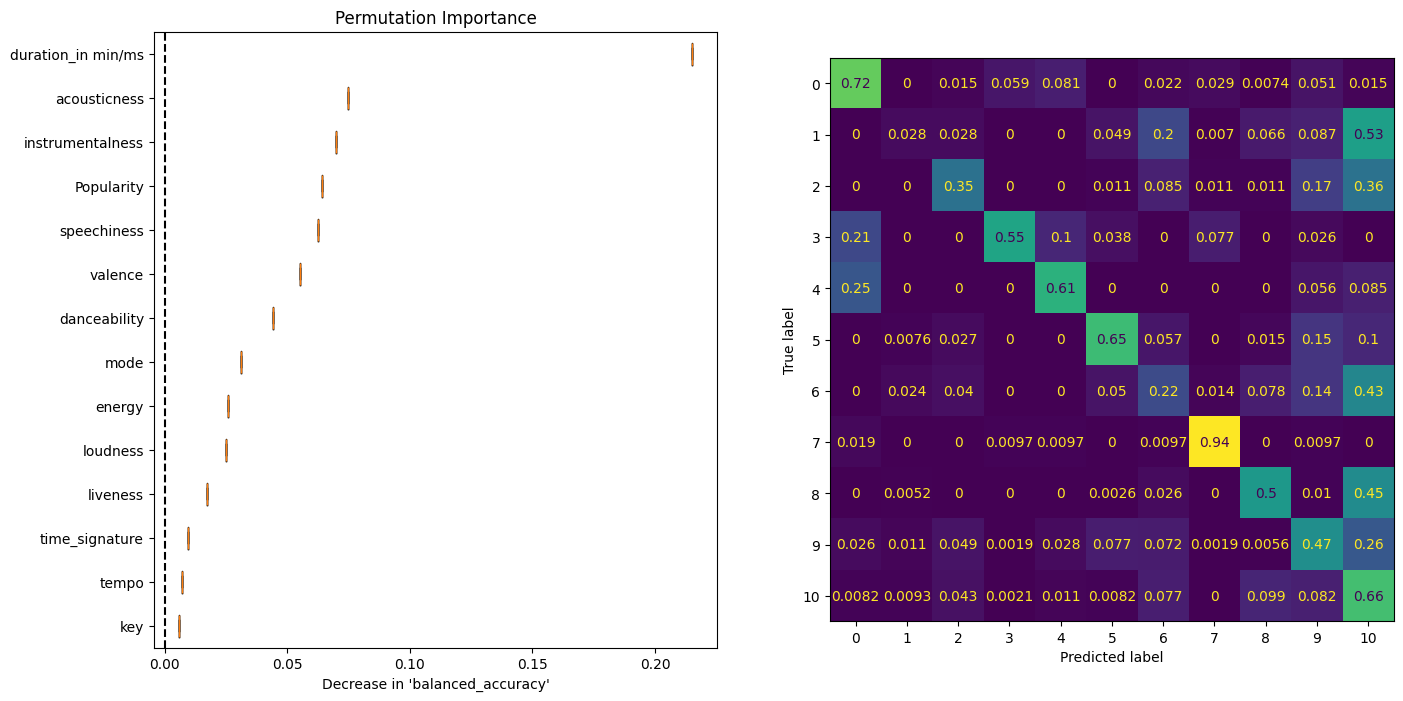

In [51]:
knn20 = mega_info(KNeighborsClassifier(20), 'true', permut_repeats=1)

Accuracy: 0.4450
Balanced Accuracy: 0.4960
5-fold Cross Val: [0.47960066 0.48894034 0.4821965  0.49138053 0.49195556]; 0.4868


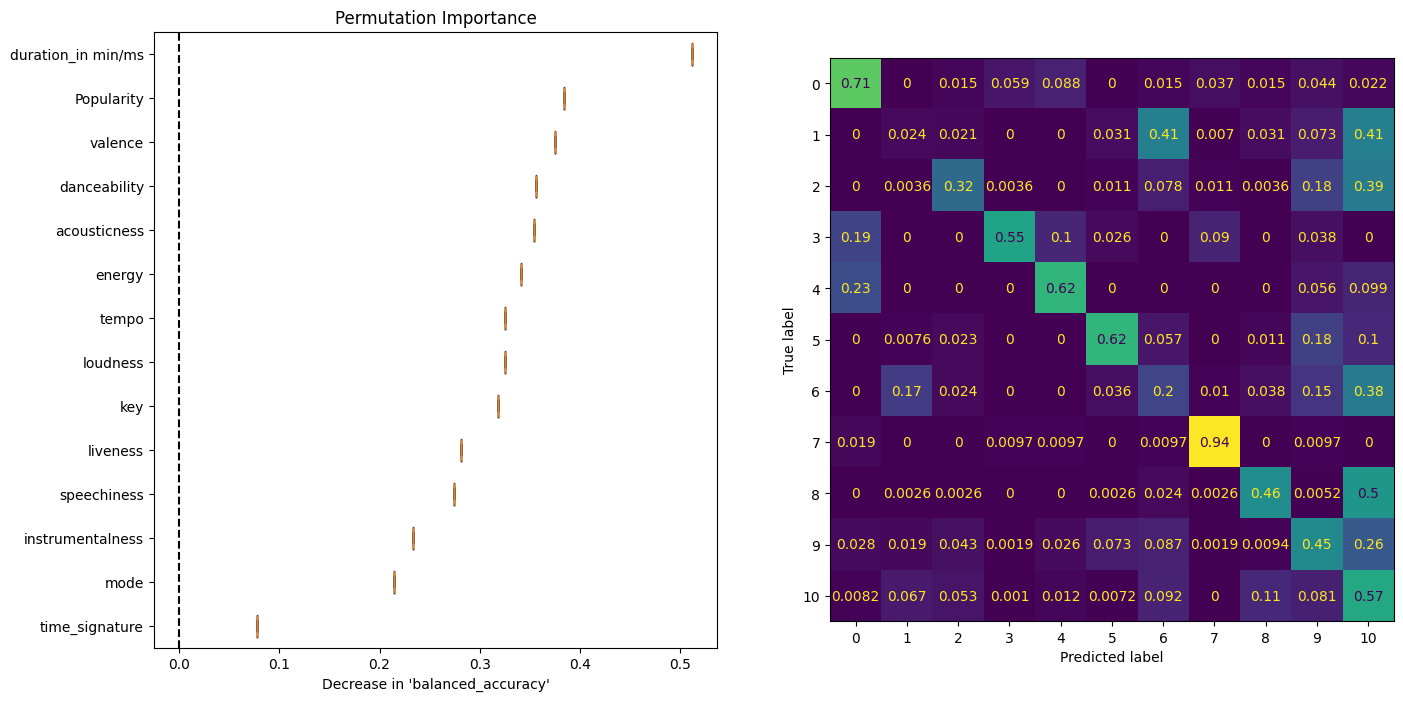

In [52]:
knn20w = mega_info(KNeighborsClassifier(20, weights='distance'), 'true', permut_repeats=1)

Accuracy: 0.4864
Balanced Accuracy: 0.5276
5-fold Cross Val: [0.51058835 0.50693279 0.5210872  0.51228157 0.51561519]; 0.5133


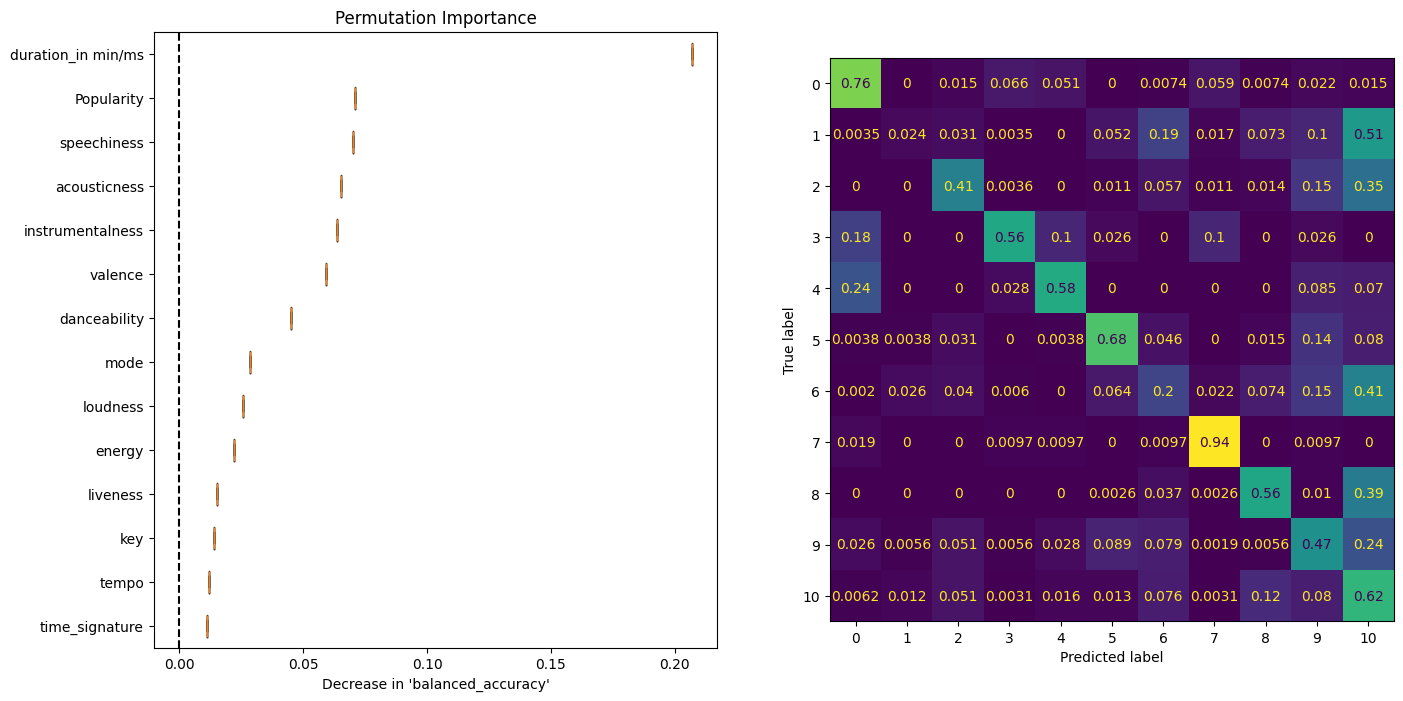

In [53]:
knn20c = mega_info(KNeighborsClassifier(20, metric='cosine'), 'true', permut_repeats=1)

Accuracy: 0.4486
Balanced Accuracy: 0.5075
5-fold Cross Val: [0.48616485 0.50107041 0.52011659 0.50396214 0.49624688]; 0.5015


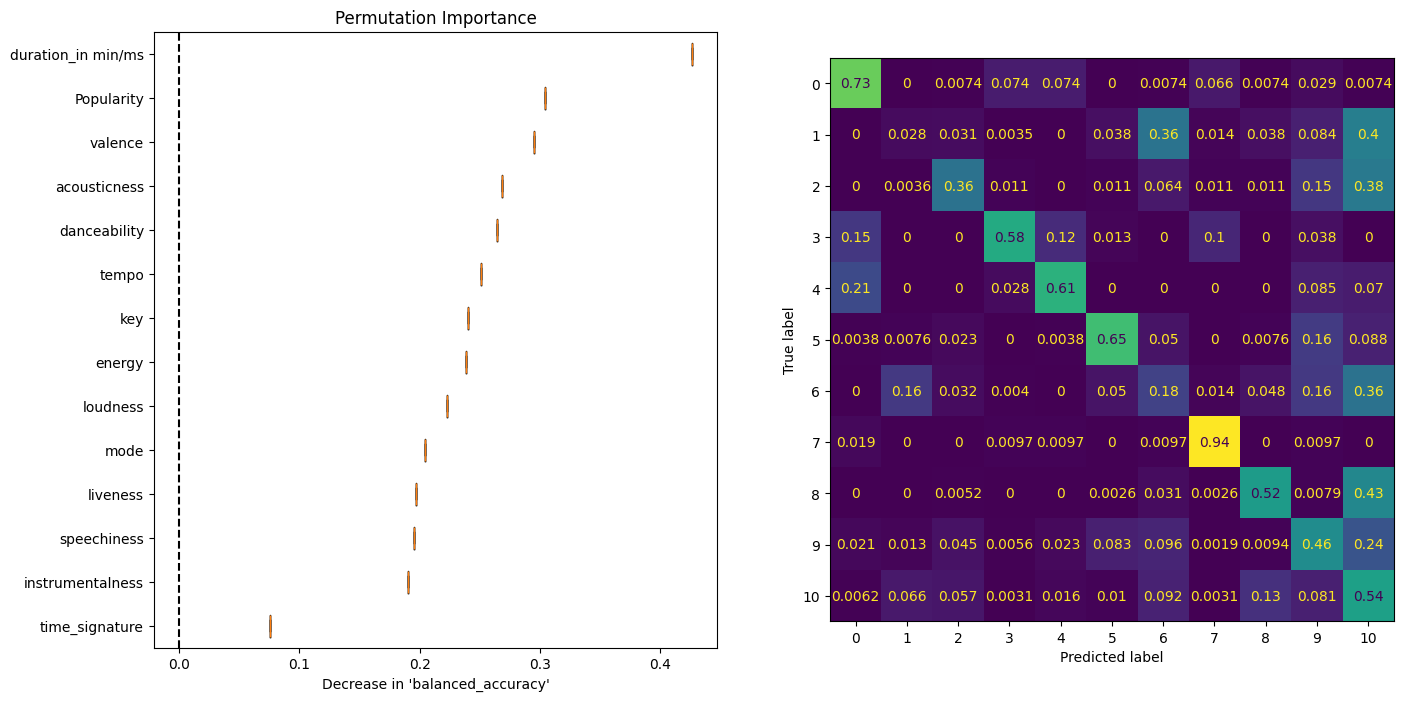

In [54]:
knn20wc = mega_info(KNeighborsClassifier(20, weights='distance', metric='cosine'), 'true', permut_repeats=1)

Accuracy: 0.4869
Balanced Accuracy: 0.5019
5-fold Cross Val: [0.46675322 0.49572359 0.48448513 0.48752267 0.49396887]; 0.4857


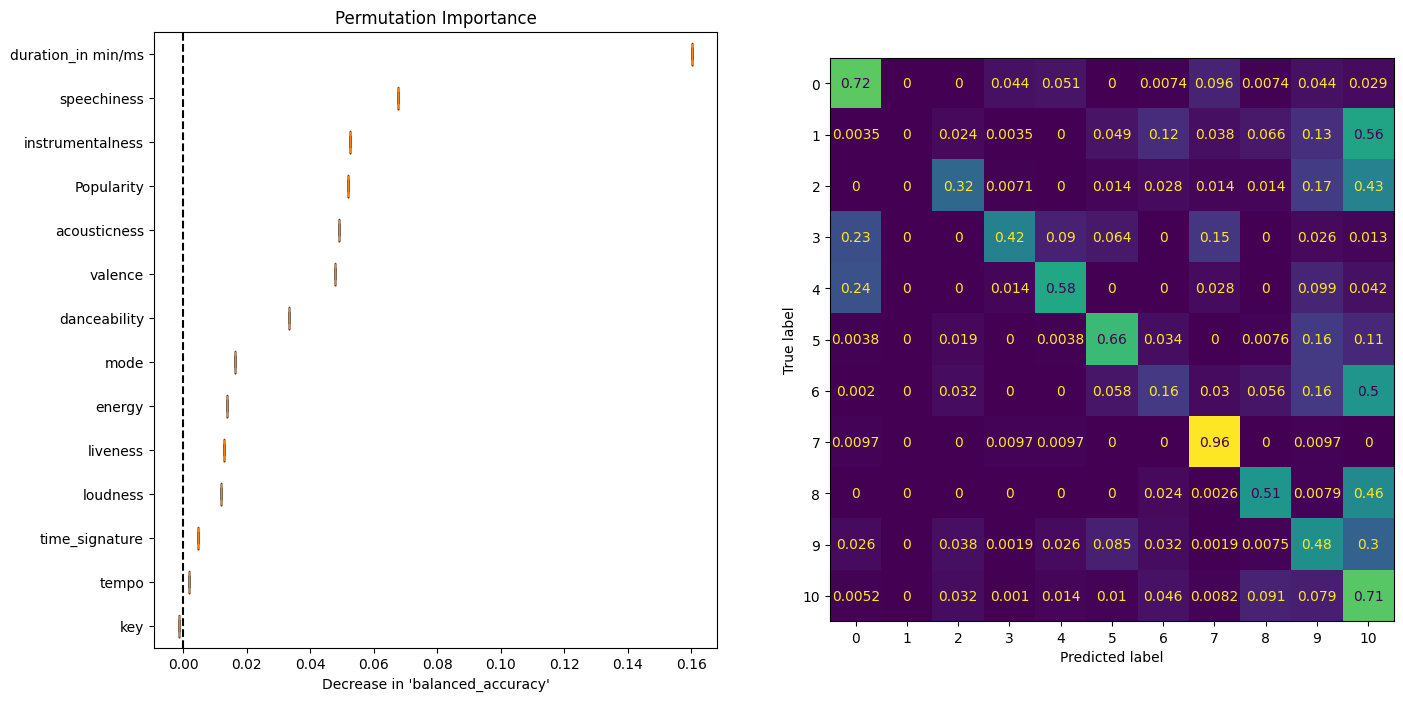

In [55]:
knn100 = mega_info(KNeighborsClassifier(100, metric='cosine'), 'true', permut_repeats=1)

### Naive Bias

In [56]:
from sklearn.naive_bayes import GaussianNB

Accuracy: 0.4378
Balanced Accuracy: 0.5122
5-fold Cross Val: [0.51441909 0.52567523 0.50724094 0.52297146 0.49909441]; 0.5139


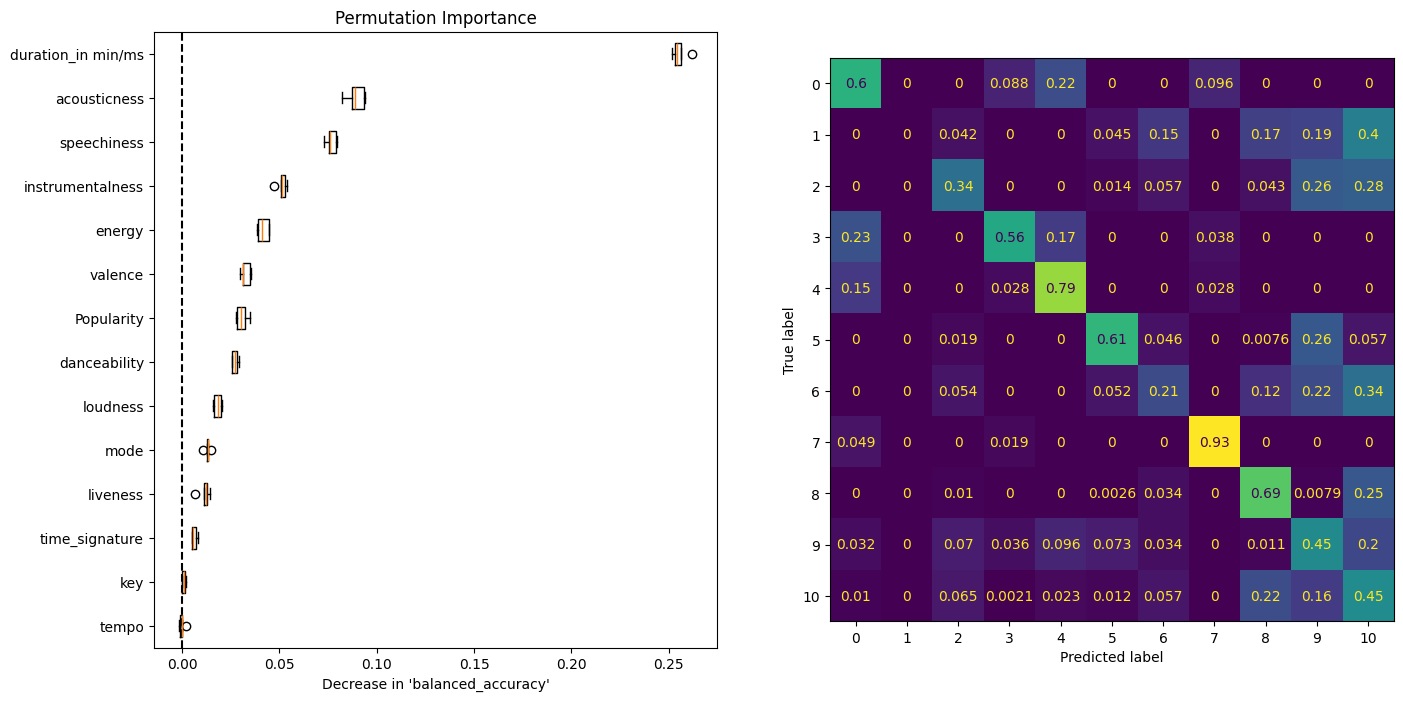

In [57]:
nb = mega_info(GaussianNB(), 'true')

In [58]:
priors = np.bincount(df_y) / len(df_x)
priors

array([0.03472994, 0.07629473, 0.07068237, 0.0223383 , 0.02150478,
       0.08040676, 0.14375417, 0.03200711, 0.10302289, 0.14025339,
       0.27500556])

Accuracy: 0.4389
Balanced Accuracy: 0.5137
5-fold Cross Val: [0.51502655 0.50942706 0.52563635 0.50850836 0.50759105]; 0.5132


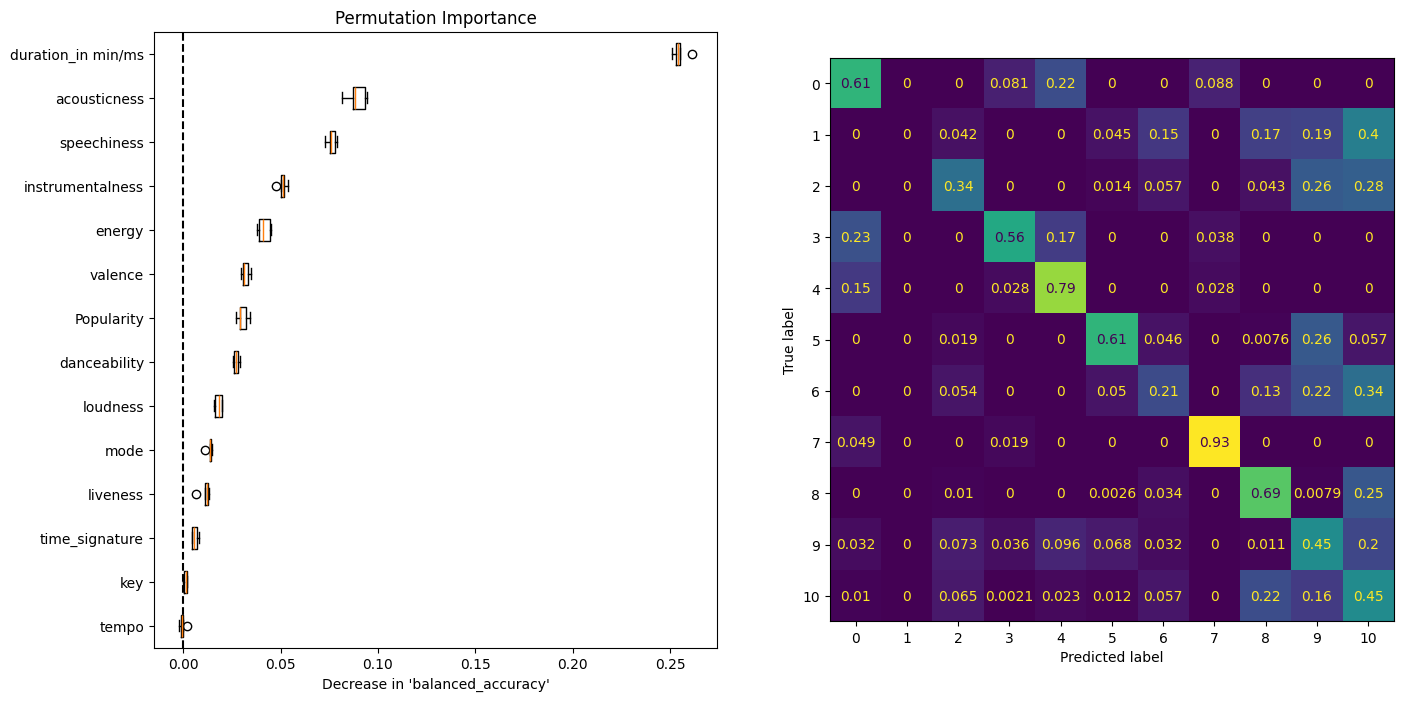

In [59]:
nb = mega_info(GaussianNB(priors=priors), 'true')

In [60]:
pd.DataFrame(zip(stats.normaltest(X_train).pvalue, [stats.shapiro(X_train[c]).pvalue for c in X_train.columns]), X_train.columns)

c:\Programs\Github\CompMath2\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 14396.
  res = hypotest_fun_out(*samples, **kwds)


,0,1
Popularity,4.393384e-07,6.208396e-18
danceability,6.230702e-17,1.317978e-14
energy,6.906824e-211,6.689176e-58
key,0.000000e+00,1.914565e-60
loudness,0.000000e+00,3.870969e-75
mode,0.000000e+00,4.594754e-101
speechiness,0.000000e+00,1.266084e-100
acousticness,0.000000e+00,2.107614e-87
instrumentalness,0.000000e+00,6.983339e-105
liveness,0.000000e+00,4.277090e-89


### Decision Tree

In [61]:
from sklearn.tree import DecisionTreeClassifier

Accuracy: 0.3644
Balanced Accuracy: 0.4542
5-fold Cross Val: [0.45492393 0.44302438 0.4430898  0.45316077 0.43020534]; 0.4449


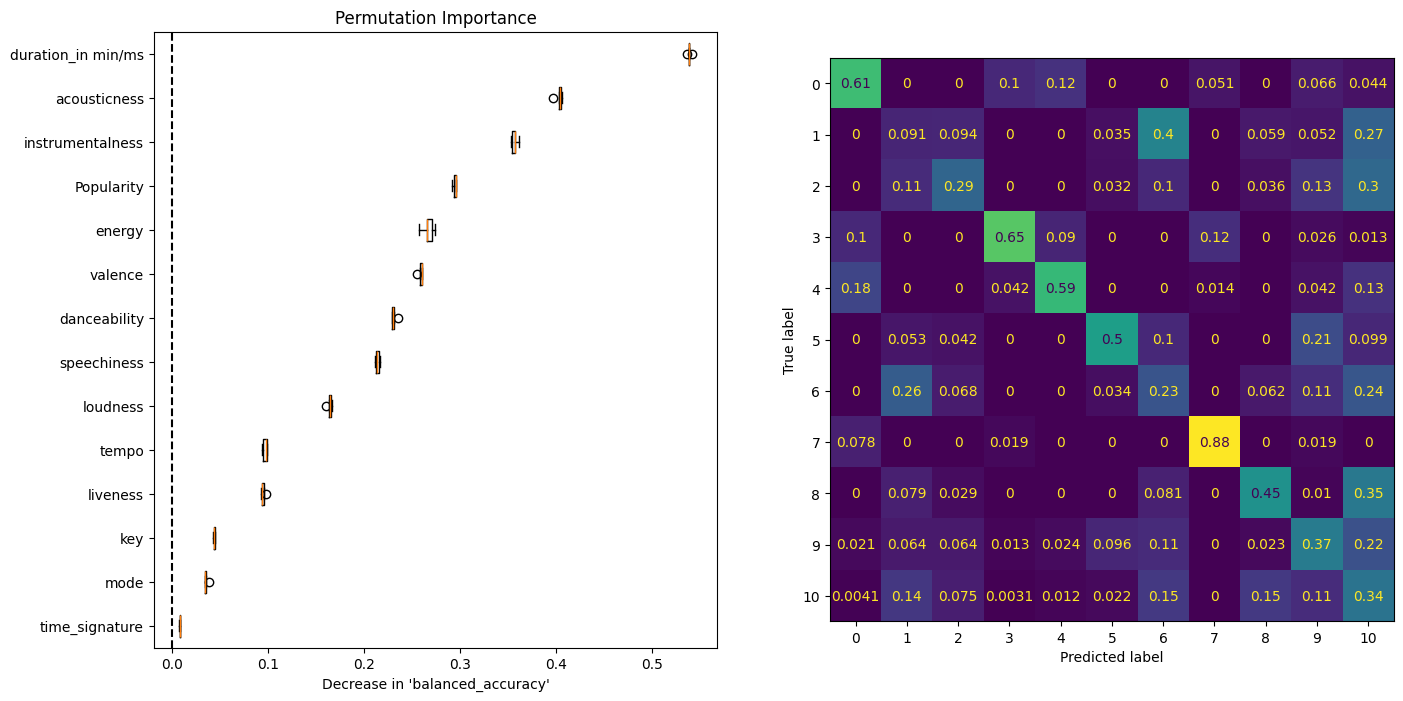

In [62]:
dtc = mega_info(DecisionTreeClassifier(), 'true')

Accuracy: 0.3664
Balanced Accuracy: 0.4662
5-fold Cross Val: [0.45214717 0.45510428 0.46347359 0.44345398 0.43469302]; 0.4498


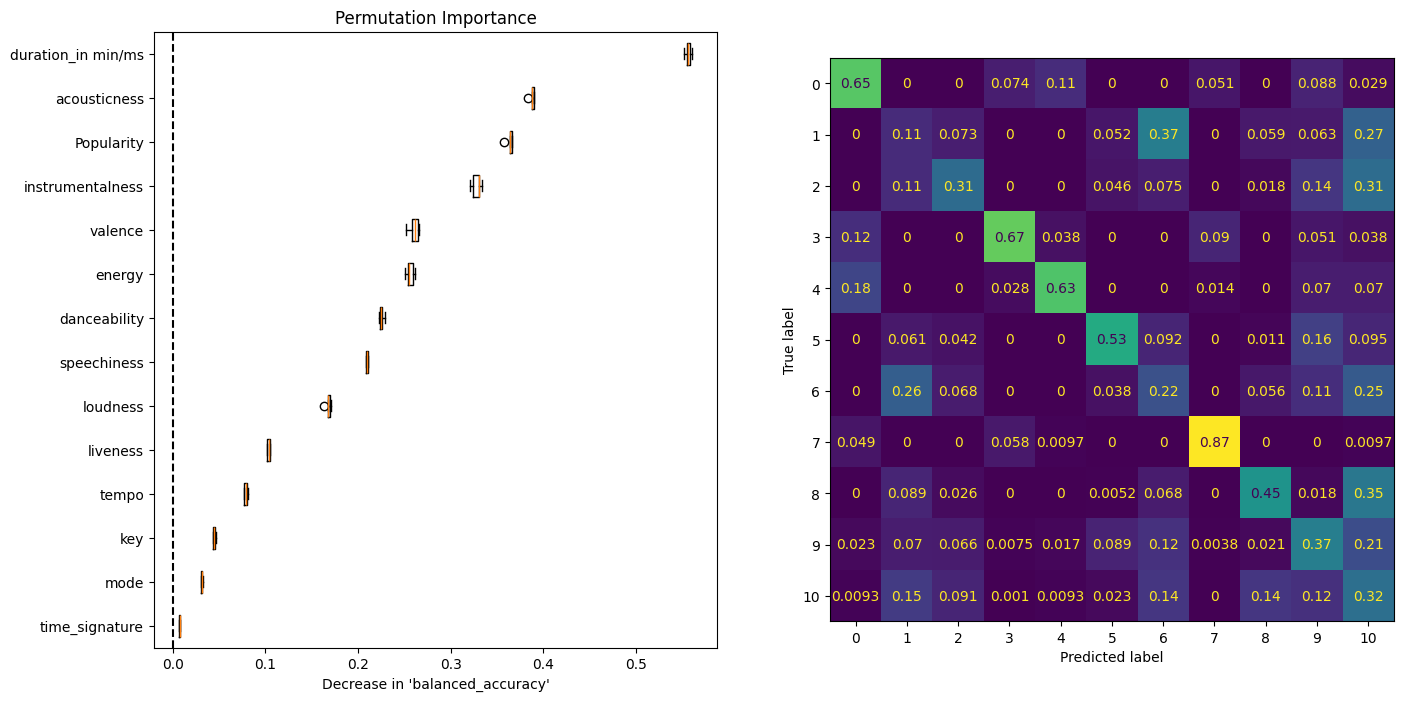

In [63]:
dtcb = mega_info(DecisionTreeClassifier(class_weight='balanced'), 'true')

Accuracy: 0.3911
Balanced Accuracy: 0.5445
5-fold Cross Val: [0.50823994 0.51834105 0.51614491 0.51675903 0.51728064]; 0.5154


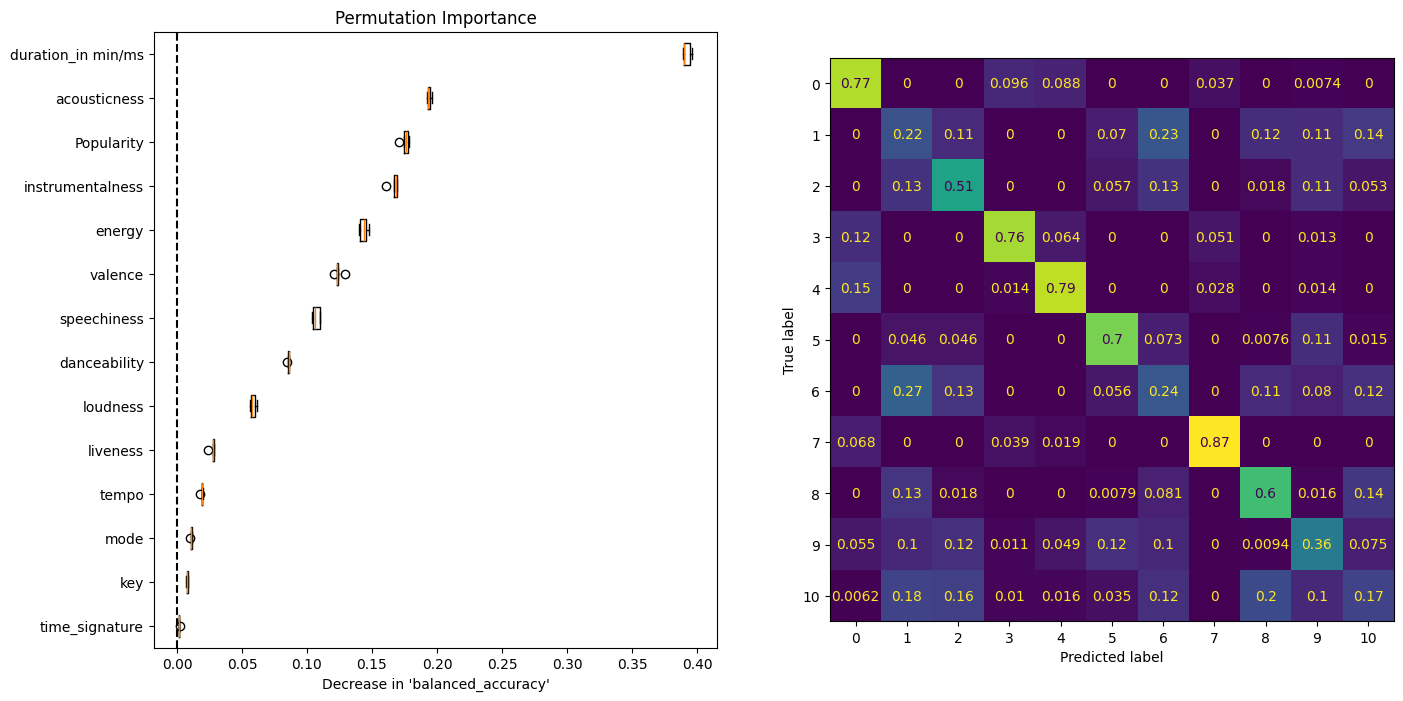

In [64]:
dtcb_12 = mega_info(DecisionTreeClassifier(min_samples_leaf=10, min_samples_split=20, class_weight='balanced'), 'true')

### Gradient Boosting

In [65]:
from sklearn.ensemble import HistGradientBoostingClassifier
from lightgbm import LGBMClassifier

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Accuracy: 0.5289
Balanced Accuracy: 0.5845
5-fold Cross Val: [0.56771174 0.55537166 0.54890942 0.56535289 0.581858  ]; 0.5638


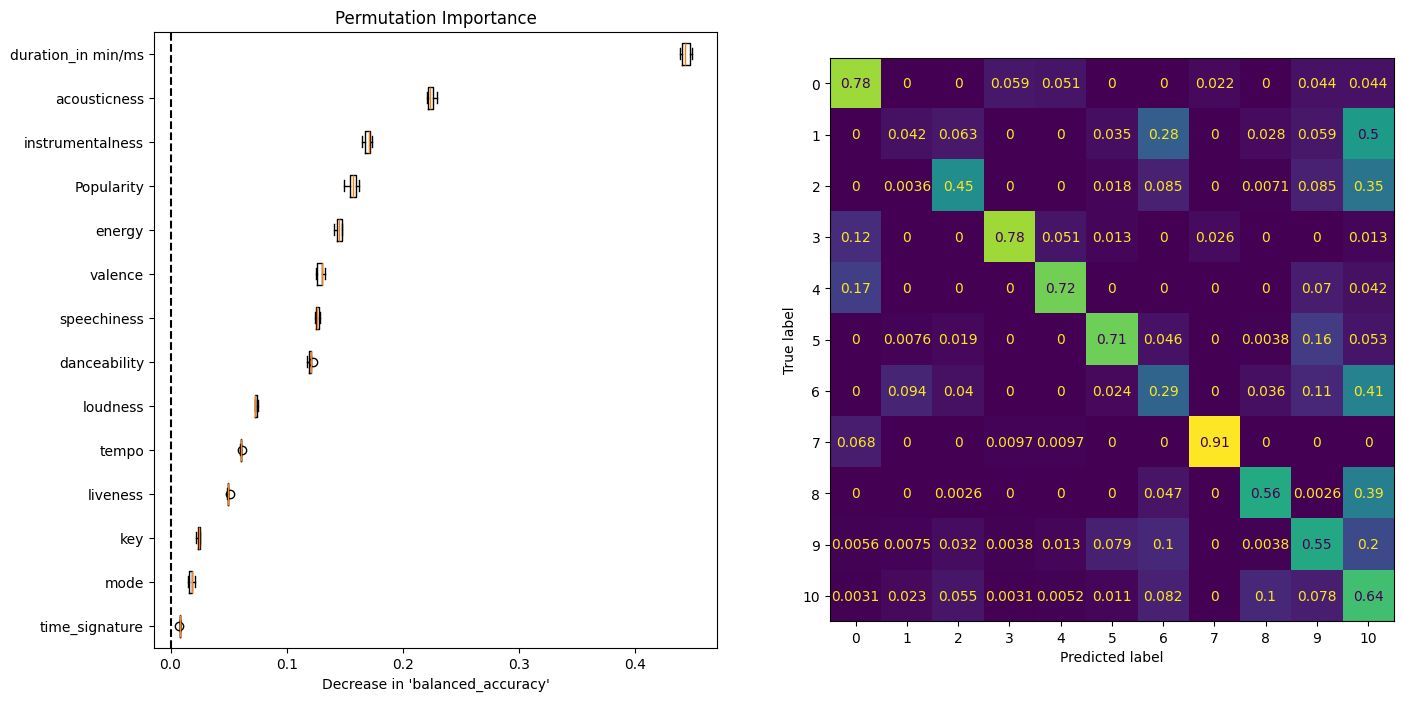

In [66]:
lgbmc = mega_info(LGBMClassifier(verbose=0), 'true')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
Accuracy: 0.4967
Balanced Accuracy: 0.6175
5-fold Cross Val: [0.58649541 0.58636032 0.58346835 0.59509592 0.58554679]; 0.5874


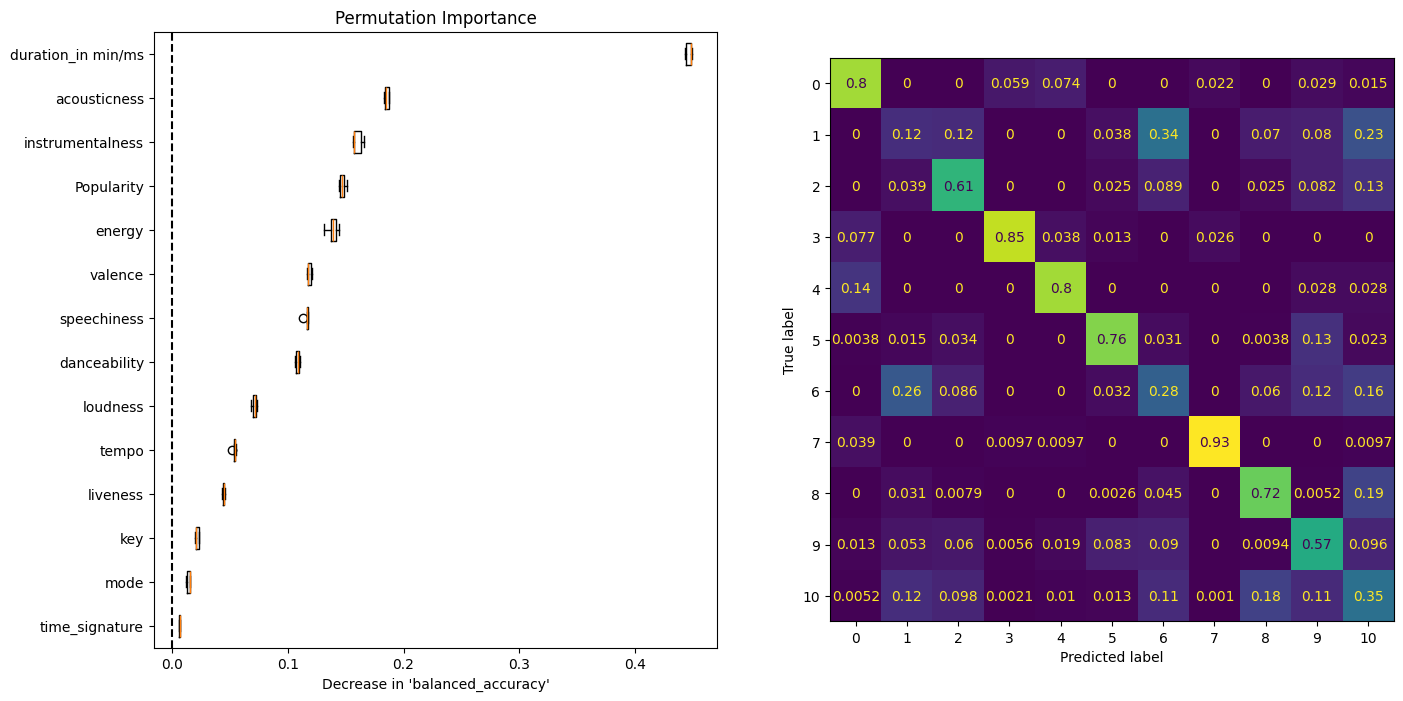

In [67]:
lgbmcb = mega_info(LGBMClassifier(class_weight='balanced', verbose=0), 'true')

Accuracy: 0.5356
Balanced Accuracy: 0.5860
5-fold Cross Val: [0.55541442 0.57029032 0.55748224 0.55180627 0.56435739]; 0.5599


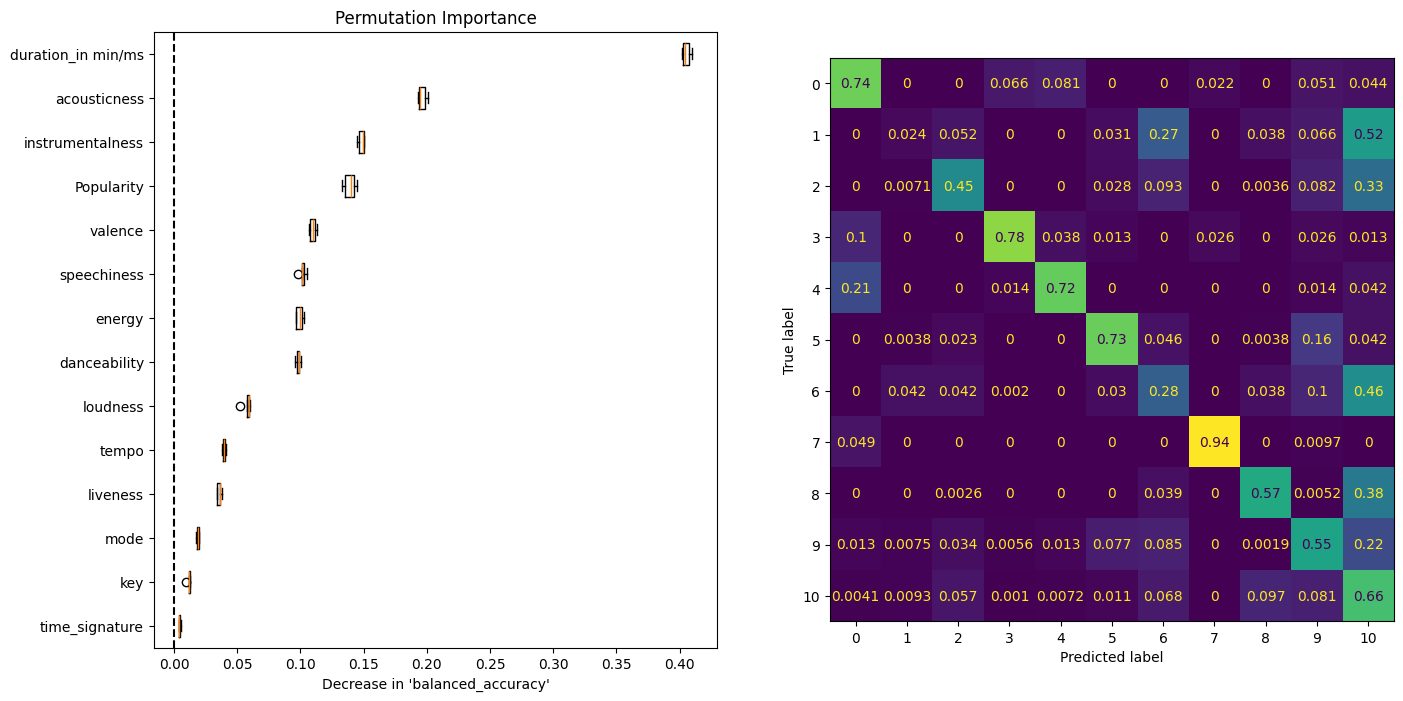

In [68]:
hgdc = mega_info(HistGradientBoostingClassifier(), 'true')

Accuracy: 0.4917
Balanced Accuracy: 0.6163
5-fold Cross Val: [0.59201898 0.58913942 0.60439829 0.59922739 0.59931469]; 0.5968


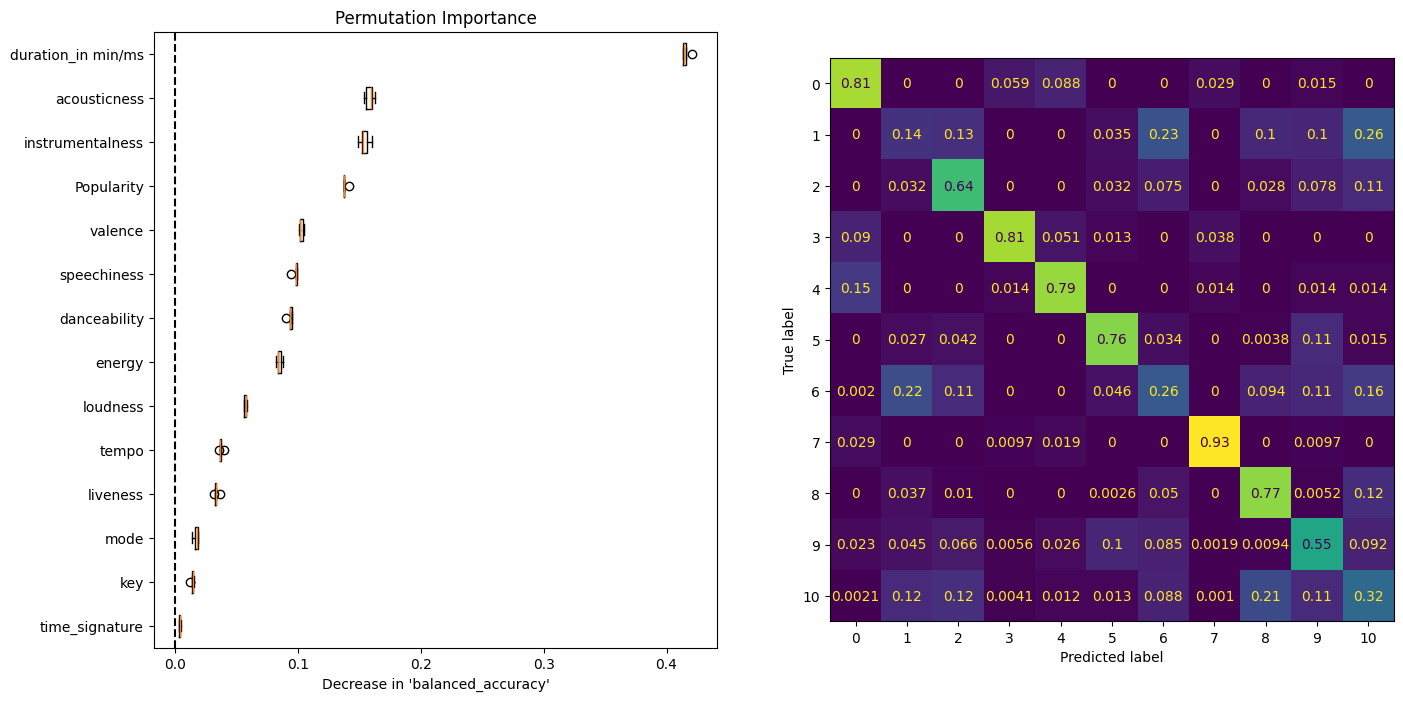

In [69]:
hgdcb = mega_info(HistGradientBoostingClassifier(class_weight='balanced'), 'true')

### SVM

In [70]:
from sklearn.svm import SVC, LinearSVC

Accuracy: 0.5272
Balanced Accuracy: 0.5500
5-fold Cross Val: [0.52199576 0.52919956]; 0.5256


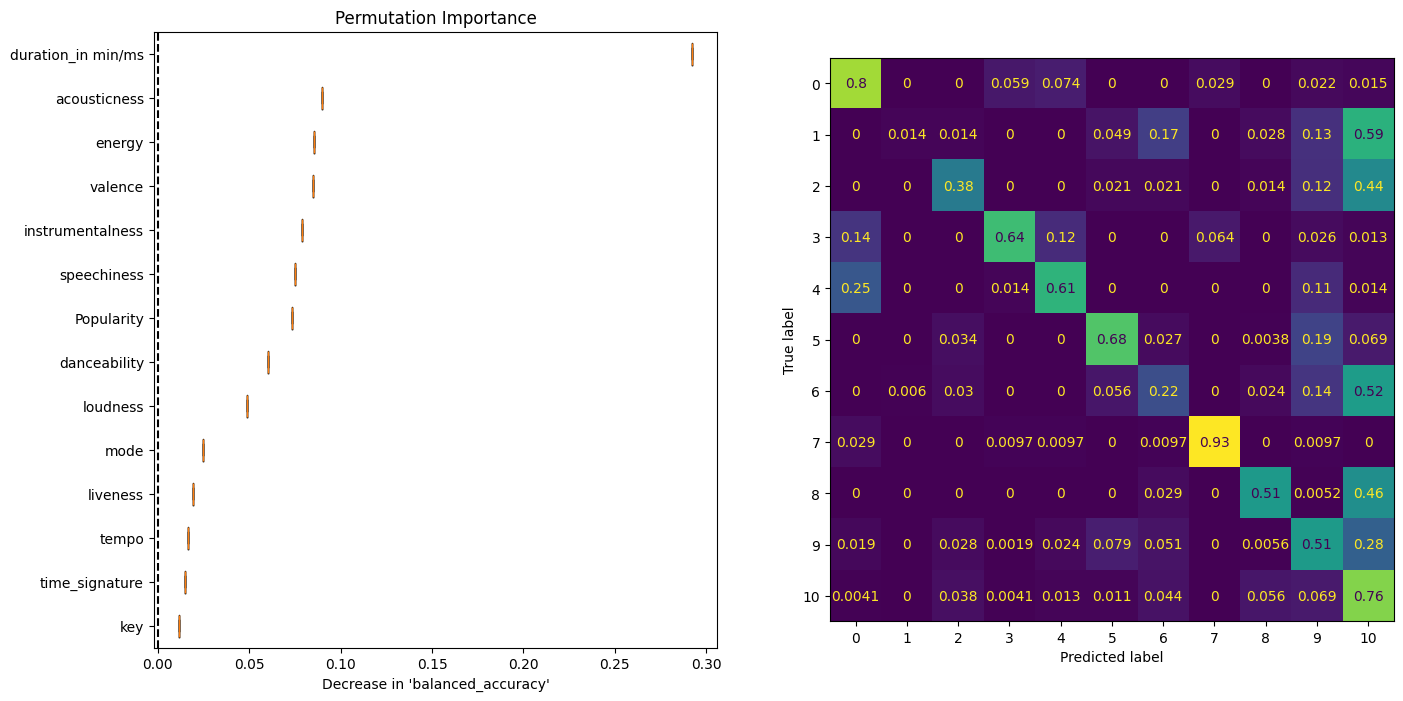

In [71]:
svc = mega_info(SVC(), 'true', kfolds=2, permut_repeats=1)

Accuracy: 0.4606
Balanced Accuracy: 0.5992
5-fold Cross Val: [0.57155018 0.58448588]; 0.5780


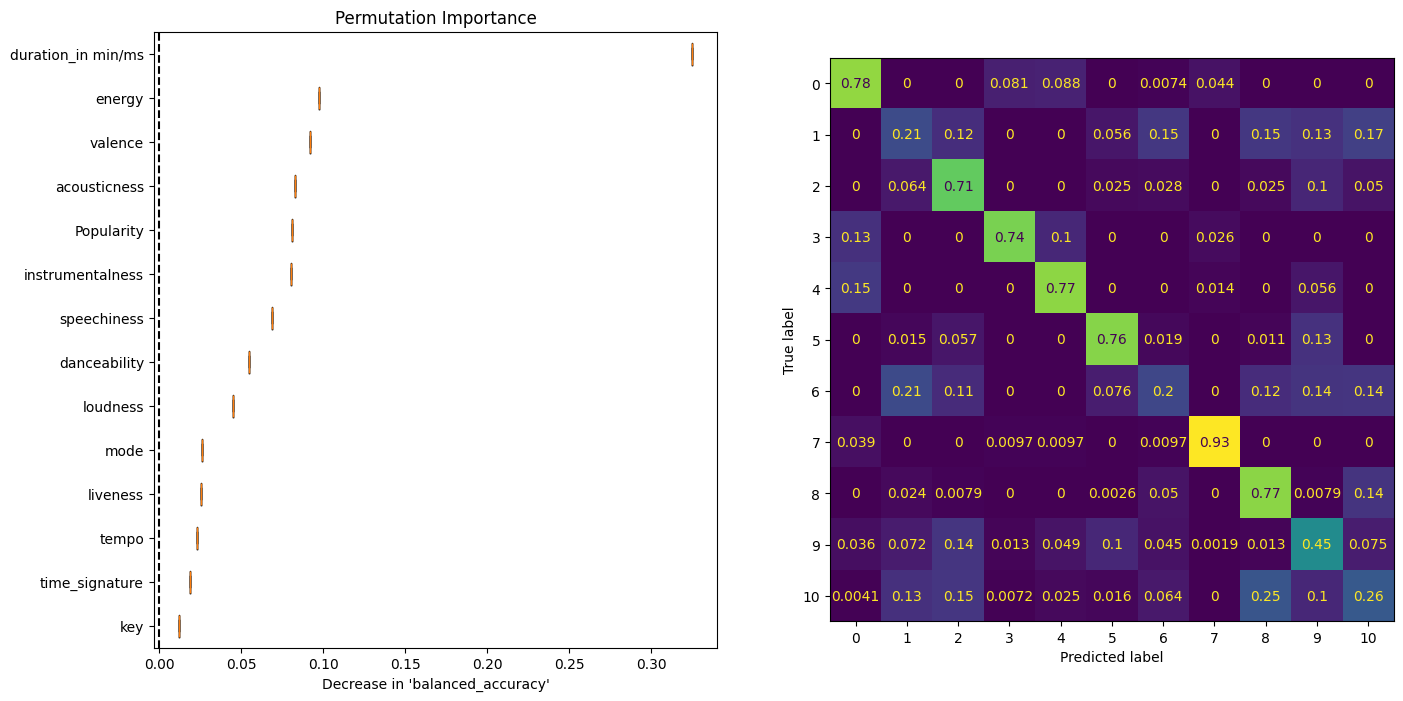

In [72]:
svcb = mega_info(SVC(class_weight='balanced'), 'true', kfolds=2, permut_repeats=1)

Accuracy: 0.4739
Balanced Accuracy: 0.5019
5-fold Cross Val: [0.4956178  0.51137497 0.49738913 0.51551825 0.50327614]; 0.5046


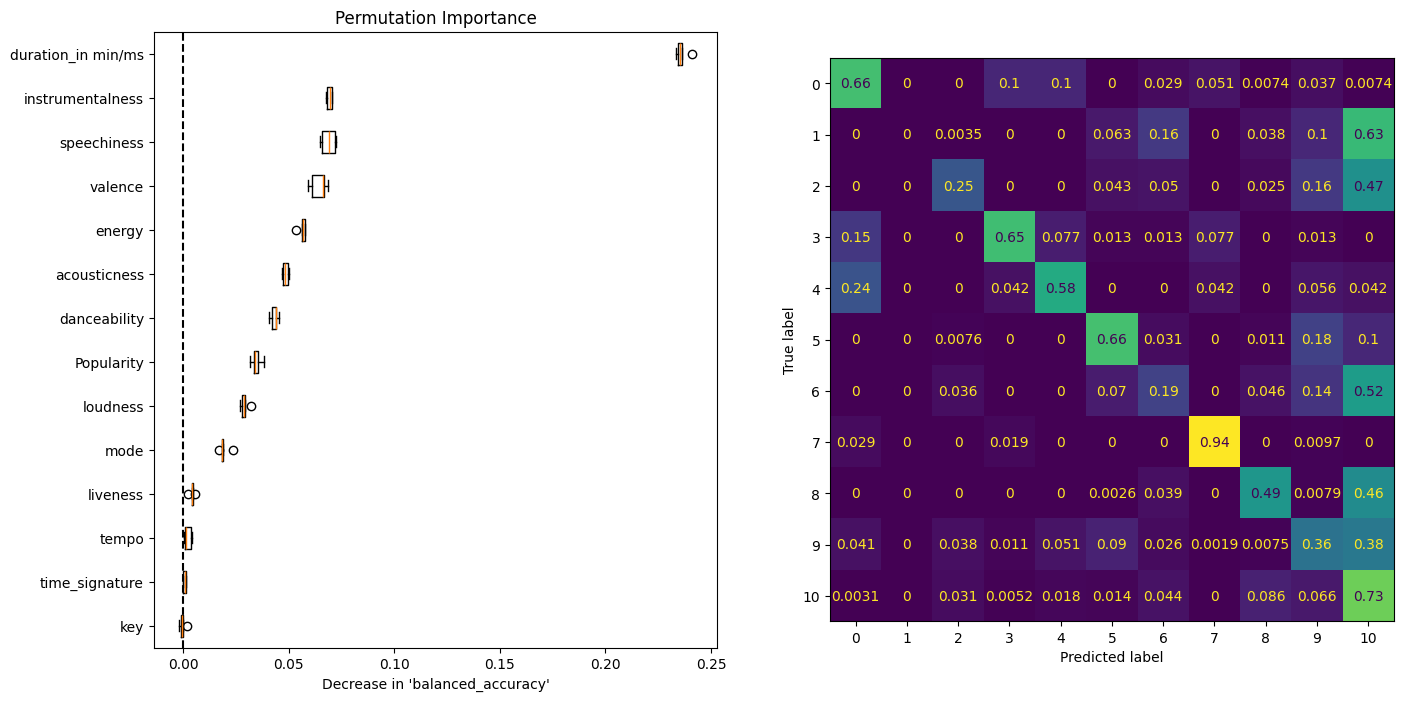

In [73]:
lsvc = mega_info(LinearSVC(), 'true')

Accuracy: 0.4361
Balanced Accuracy: 0.5579
5-fold Cross Val: [0.55781026 0.53125294 0.56592608 0.54988581 0.57128429]; 0.5552


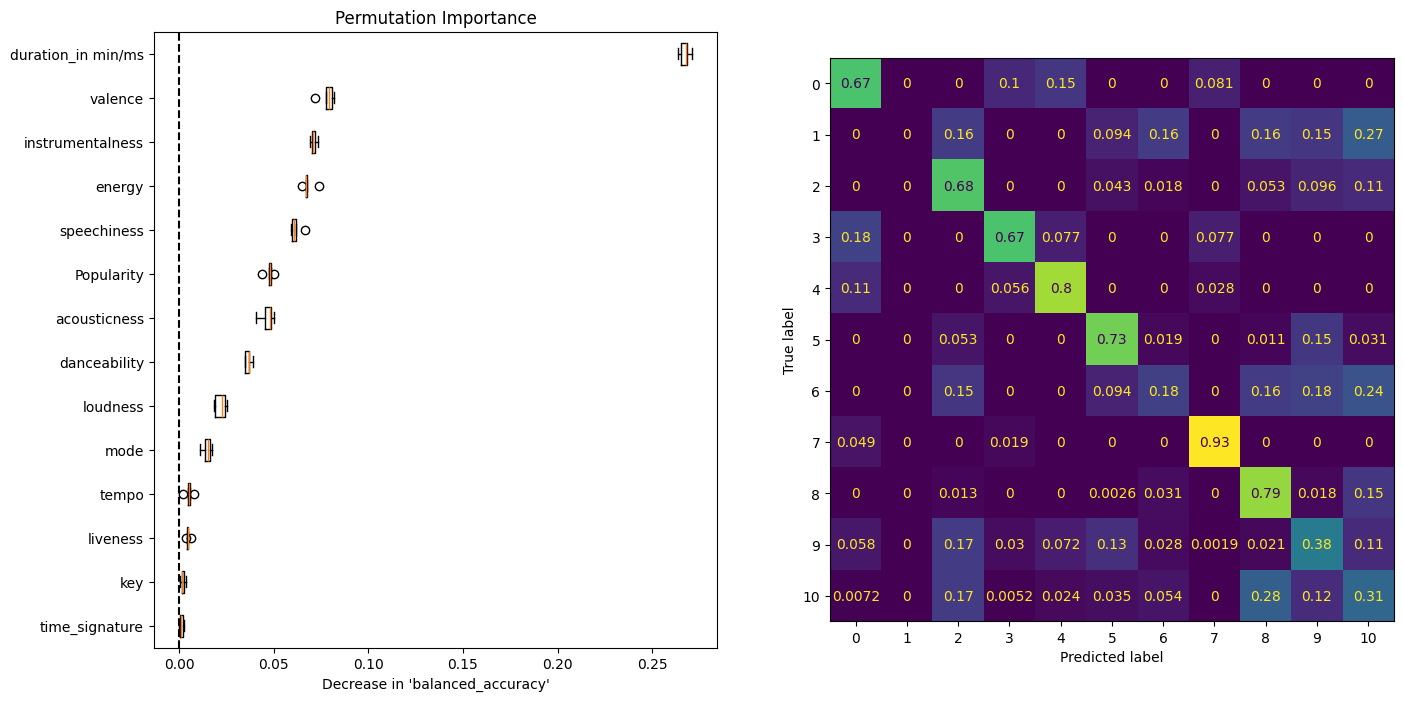

In [74]:
lsvcb = mega_info(LinearSVC(class_weight='balanced'), 'true')

### MLP

In [75]:
from sklearn.neural_network import MLPClassifier

Accuracy: 0.5161
Balanced Accuracy: 0.5709
5-fold Cross Val: [0.54843691 0.54563494 0.53965226 0.54599035 0.55219318]; 0.5464


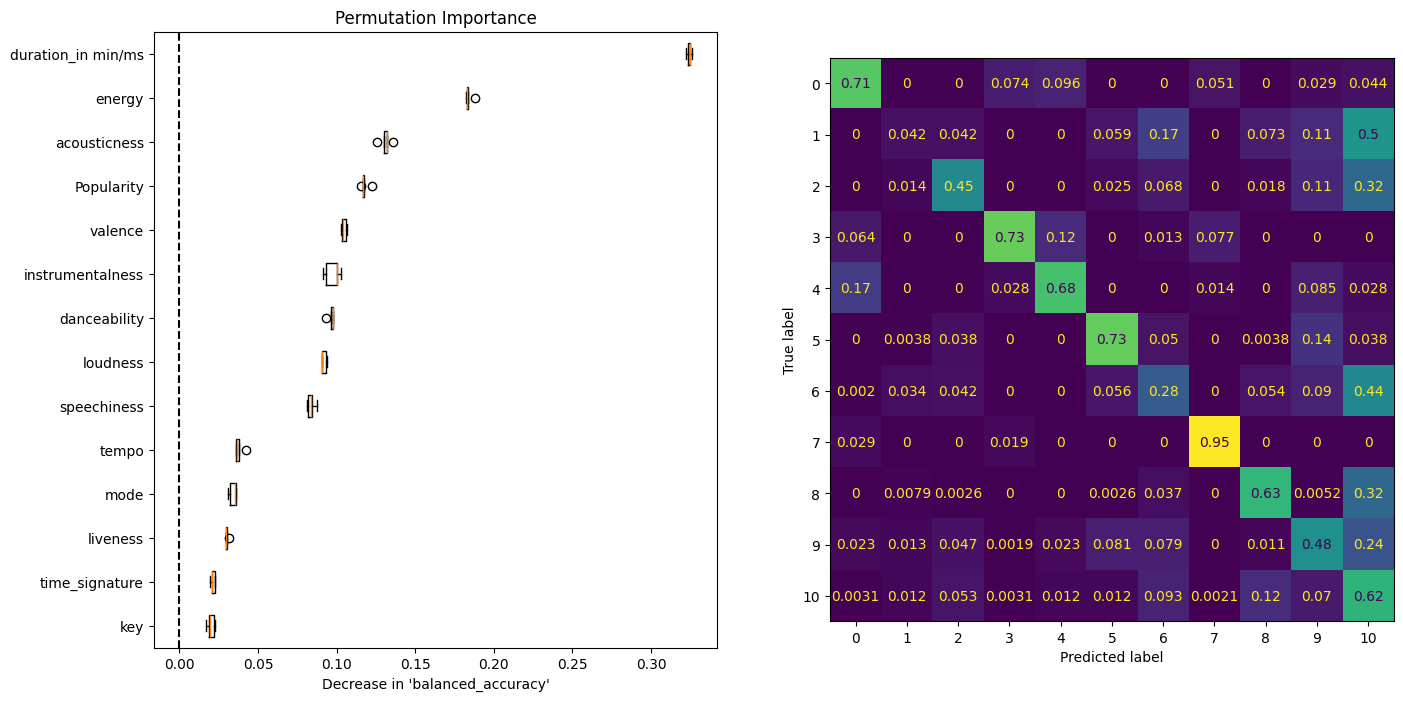

In [76]:
mlp = mega_info(MLPClassifier(max_iter=1000), 'true')

In [77]:
import keras

In [78]:
class MLPModel(keras.Sequential):
    def score(self, X, y):
        y_pred = self.predict(X)
        return metrics.accuracy_score(y, y_pred)
    
    def predict(self, X):
        y_pred = super().predict(X)
        return y_pred.argmax(axis=1)
    
    def __repr__(self):
        print()
        return f"{self.__class__.__qualname__}({[l.units for l in self.layers if isinstance(l, keras.layers.Dense)]})"

model = MLPModel([
    keras.layers.Input((len(df_x.columns),), name='i'),
    keras.layers.Dense(100, name='d1'),
    keras.layers.ReLU(name='relu'),
    keras.layers.Dense(len(np.unique(df_y)), name='do'),
    keras.layers.Softmax(name='softmax')
])

In [79]:
model.compile(
    optimizer='adam', 
    loss=keras.losses.SparseCategoricalCrossentropy(),
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013 - val_loss: 2.0498
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0010 - val_loss: 1.7759
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.6298e-04 - val_loss: 1.6364
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9252e-04 - val_loss: 1.5642
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.5324e-04 - val_loss: 1.5075
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.3000e-04 - val_loss: 1.4890
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1365e-04 - val_loss: 1.4762
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0164e-04 - val_loss: 1.4487
Epoch 9/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9306e-04 - val_loss: 1.4316
Epoch 10/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8636e-04 - val_loss: 1.4228
Epoch 11/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8043e-04 - val_loss: 1.4239
Epoch 12/100
57/57 ━━━━━━━━

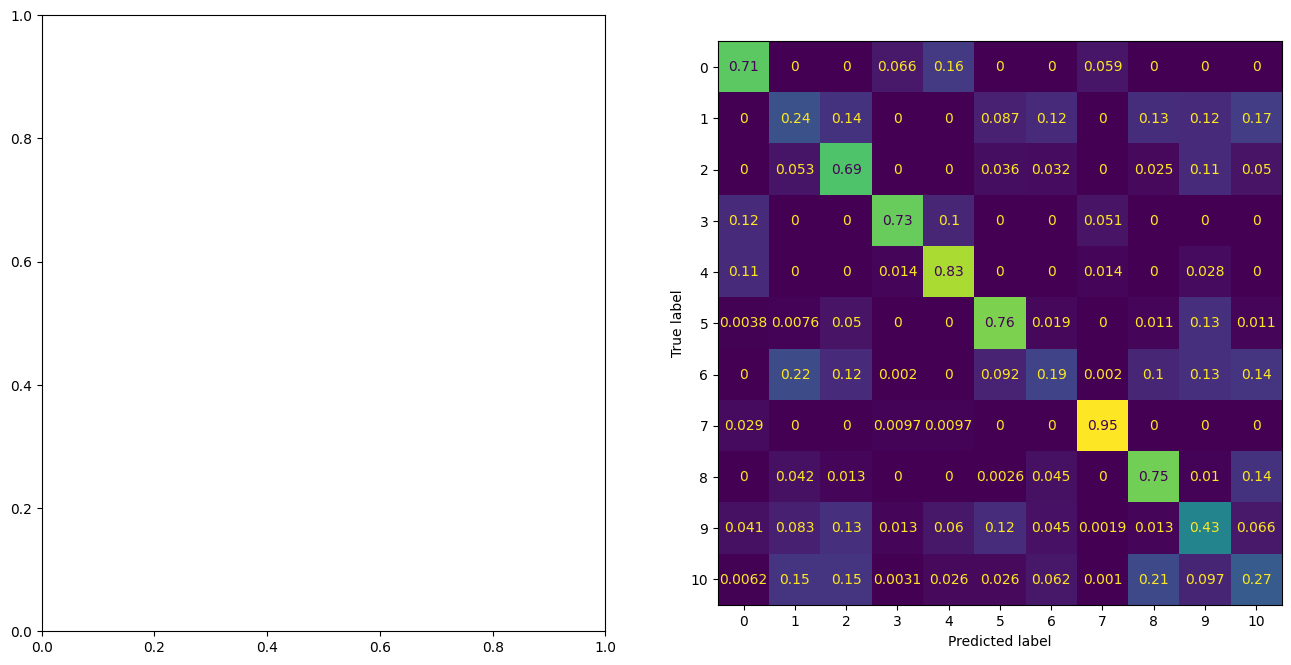

In [80]:
mlp_k = mega_info(
    model, 
    'true', 
    fit_kwargs={
        "epochs": 100, "batch_size": 256, "validation_data": (X_test, y_test), "class_weight": dict(zip(range(N_CLASSES), class_weights)),
        "callbacks": [keras.callbacks.EarlyStopping(patience=5)]
    }, 
    is_kflod=False,
    permut_repeats=0,
)

### Ensemble

In [81]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

Accuracy: 0.5008
Balanced Accuracy: 0.5701
5-fold Cross Val: [0.55397232 0.5529609  0.53474772 0.5581068  0.55819083]; 0.5516


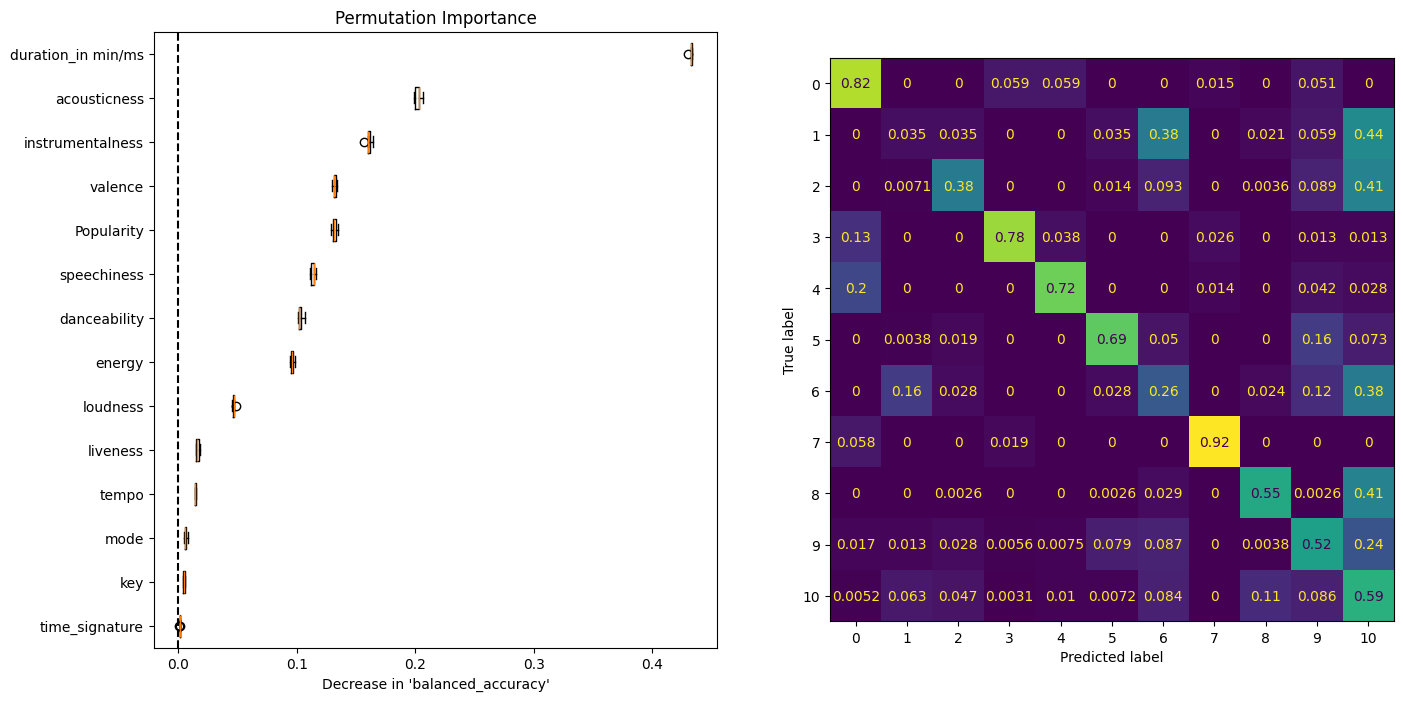

In [82]:
rfc = mega_info(RandomForestClassifier(random_state=42, class_weight='balanced'), 'true')

Accuracy: 0.4814
Balanced Accuracy: 0.6084
5-fold Cross Val: [0.59772245 0.57707941 0.58652009 0.59710208 0.58135452]; 0.5880


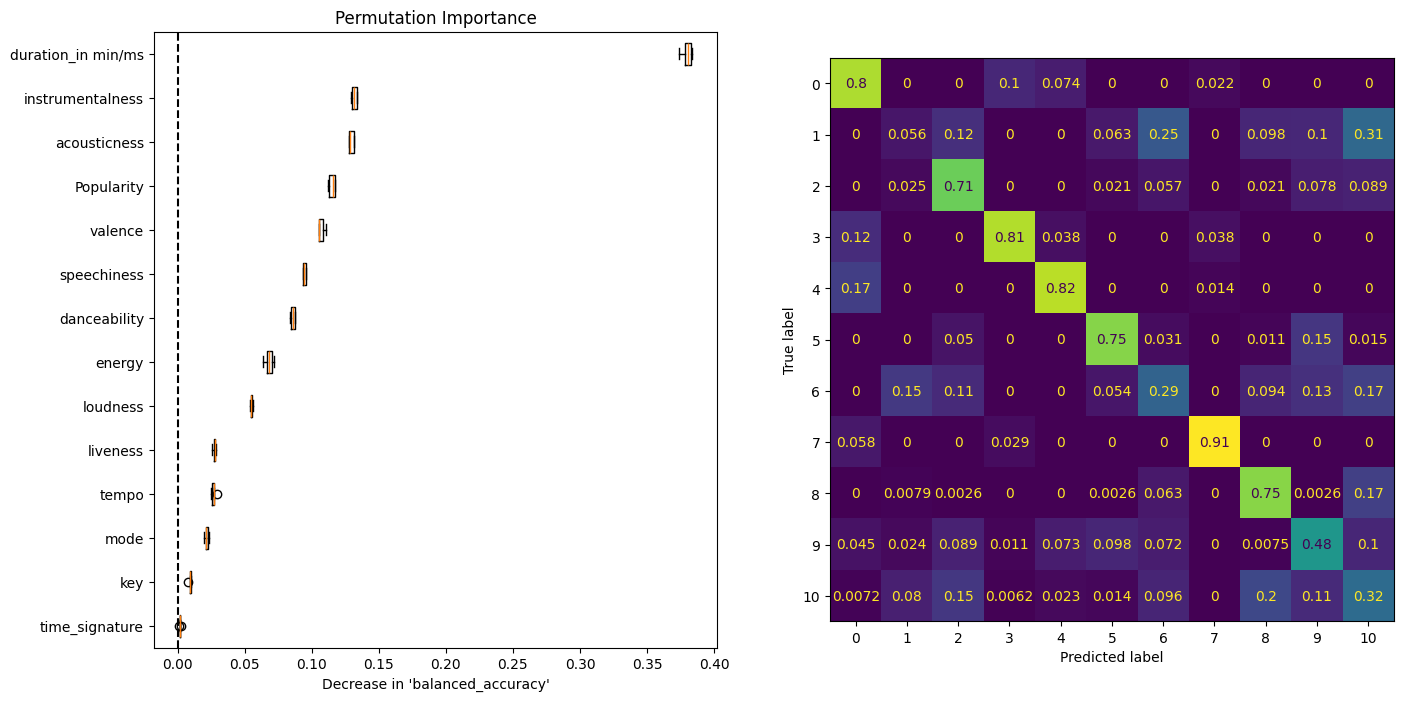

In [83]:
rfc_12 = mega_info(RandomForestClassifier(random_state=42, class_weight='balanced', min_samples_leaf=10, min_samples_split=20), 'true')

Accuracy: 0.4864
Balanced Accuracy: 0.5860
5-fold Cross Val: [0.56706885 0.57979234]; 0.5734


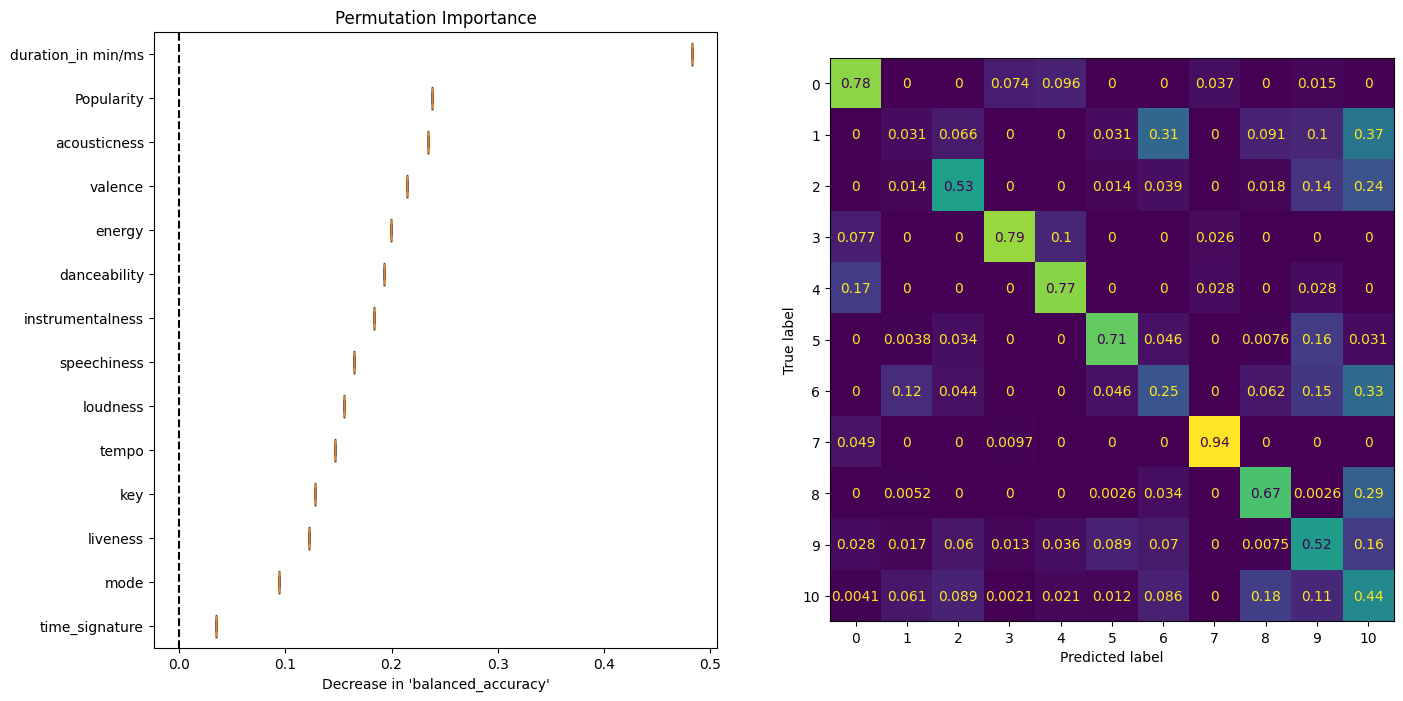

In [84]:
vc = mega_info(
    VotingClassifier([
        ("NB", nb),
        ("kNN20", knn20wc),
        ("DecTree", dtcb_12),
        ("HistGradBoost", hgdcb),
        ("mlp", mlp),
    ], voting='soft'),
    'true',
    kfolds=2,
    permut_repeats=1,
)

Accuracy: 0.4889
Balanced Accuracy: 0.5890
5-fold Cross Val: [0.56189409 0.56149016]; 0.5617


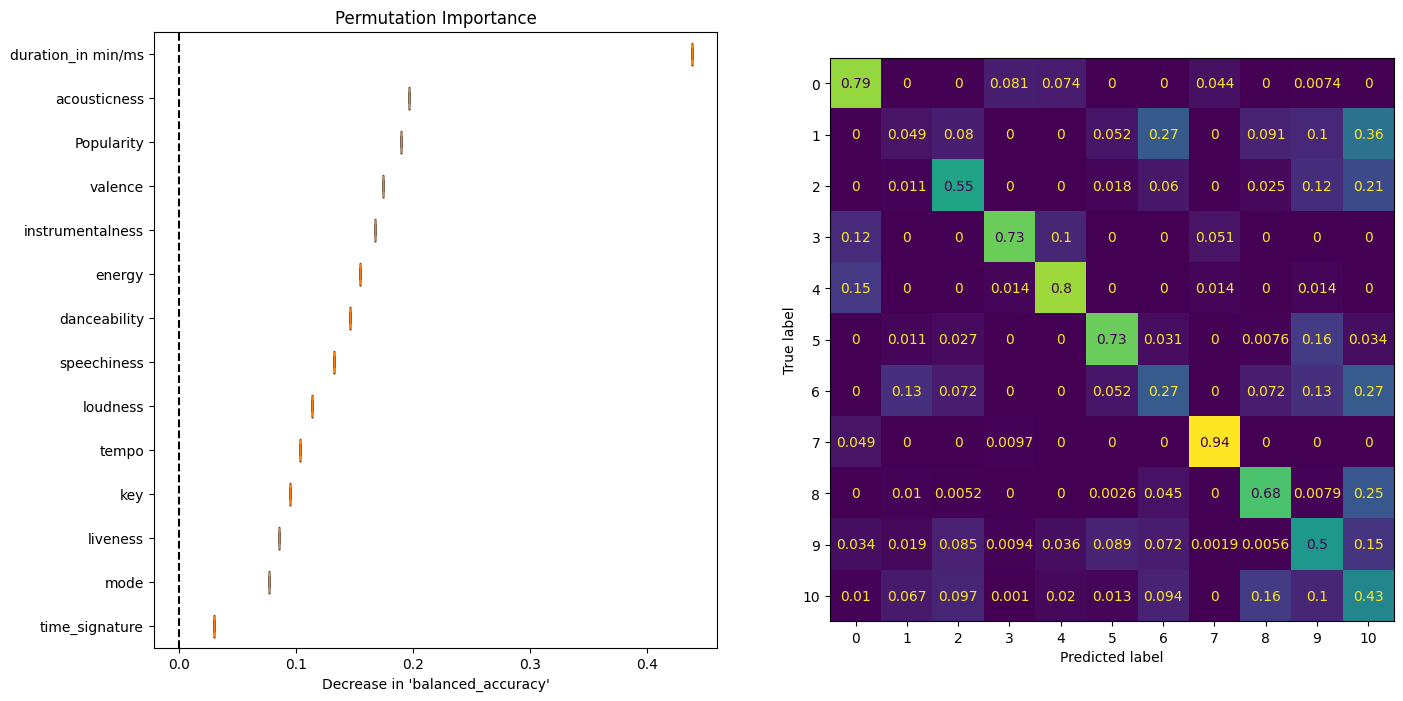

In [85]:
vch = mega_info(
    VotingClassifier([
        ("NB", nb),
        ("kNN20", knn20wc),
        ("DecTree", dtcb_12),
        ("HistGradBoost", hgdcb),
        ("mlp", mlp),
    ], voting='hard'),
    'true',
    kfolds=2,
    permut_repeats=1,
)

# Results

In [ ]:
# saved_accuracy = dict(list(saved_accuracy.items())[:35])

In [160]:
pd.DataFrame(saved_accuracy, ["acc", "bal_acc", "kfold_bal_acc"]).T

,acc,bal_acc,kfold_bal_acc
OneRule(),0.040000,0.077294,0.079919
LogisticRegression(max_iter=10000),0.487222,0.522477,0.523647
"LogisticRegression(class_weight='balanced', max_iter=10000)",0.439444,0.565055,0.561591
"LogisticRegression(class_weight='balanced', l1_ratio=1, max_iter=10000,\n solver='saga')",0.439722,0.565383,0.562482
KNeighborsClassifier(),0.425278,0.494224,0.496468
KNeighborsClassifier(weights='distance'),0.409167,0.474362,0.476758
KNeighborsClassifier(n_neighbors=20),0.484444,0.517182,0.506829
"KNeighborsClassifier(n_neighbors=20, weights='distance')",0.445000,0.496034,0.486815
"KNeighborsClassifier(metric='cosine', n_neighbors=20)",0.486389,0.527611,0.513301
"KNeighborsClassifier(metric='cosine', n_neighbors=20, weights='distance')",0.448611,0.507471,0.501512


In [87]:
feature_importance(dtcb_12, rfc_12, lgbmcb)

,0,1,2
duration_in min/ms,0.215761,0.229705,3549
instrumentalness,0.153817,0.089109,2607
acousticness,0.126413,0.118323,2964
Popularity,0.114427,0.083482,3118
speechiness,0.091925,0.092186,2985
valence,0.076957,0.075871,2906
energy,0.072924,0.096319,2692
loudness,0.048119,0.072608,2580
danceability,0.040126,0.065571,2885
liveness,0.024235,0.028633,2566


(<Axes: >, <Axes: >)

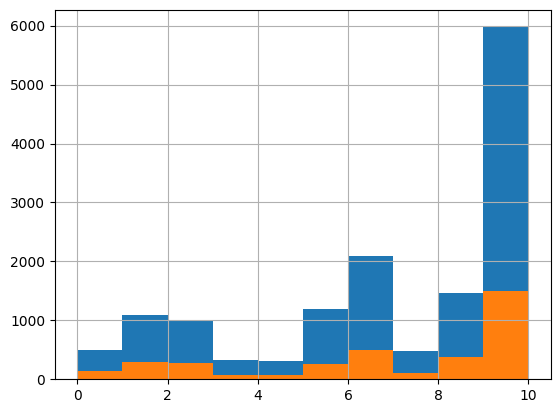

In [88]:
y_train.hist(), y_test.hist()

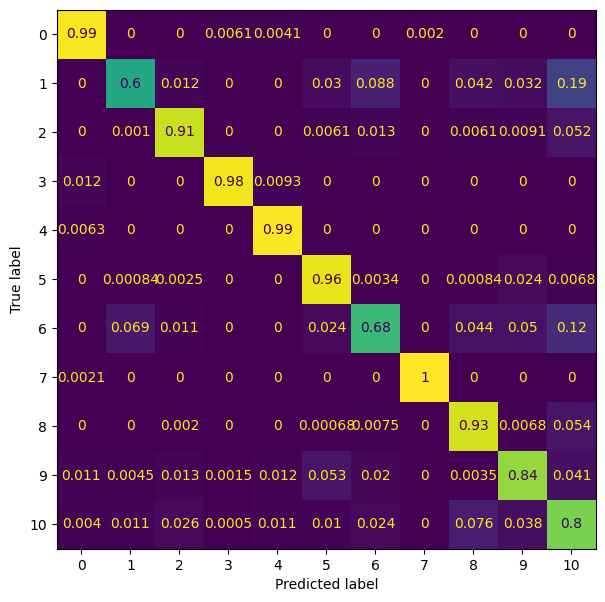

In [89]:
confusion_matrix(y_train, vc.predict(X_train), normalize='true')

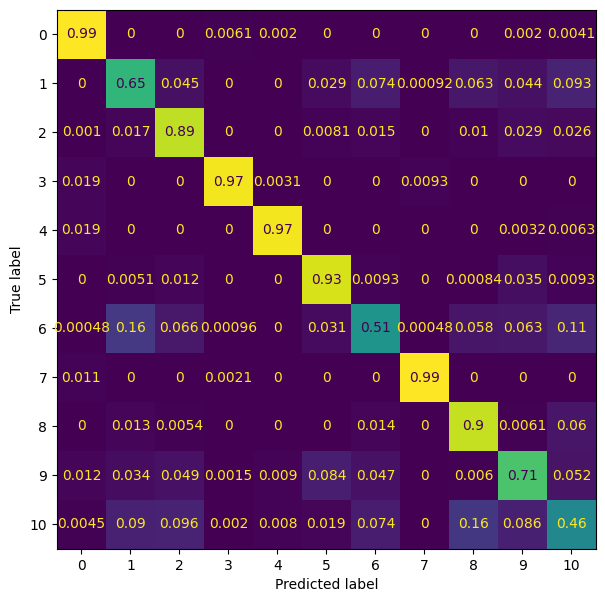

In [90]:
confusion_matrix(y_train, hgdcb.predict(X_train), normalize='true')